# SPH6004 Advanced Statistical Learning - Individual Assignment 1

## Predicting Patient Discharge from ICU using MIMIC-IV Data

**Objective:** Develop a predictive model to estimate a patient's chance of being discharged from the Intensive Care Unit (ICU), using a pre-extracted static dataset from MIMIC-IV v3.1.

**Target Variable:** `hospital_expire_flag` (0 = Discharged, 1 = Expired)

### Report Outline
1. **Problem Statement** 
2. **Data Exploration & Preprocessing**
3. **Feature Selection Strategy** (Part 2)
4. **Predictive Models & Performance Comparison** (Part 3)
5. **Summary & Key Findings**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Feature Selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.feature_selection import RFE, VarianceThreshold

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier  # For feature importance comparison

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Data Loading & Exploration

In [2]:
# Load dataset
df = pd.read_csv(r'D:\study\SPH 6004\Assignment1_mimic dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of patients: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (65366, 140)
Number of patients: 65366
Number of features: 140

First 5 rows:


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,deathtime,icu_death_flag,...,ck_mb_min,ck_mb_max,ggt_min,ggt_max,ld_ldh_min,ld_ldh_max,so2_min,so2_max,po2_min,po2_max
0,10270110,20171261,35854639,PACU,PACU,2134-03-25T03:32:02Z,2134-03-25T14:20:42Z,0.450463,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10270644,20019675,35548343,PACU,PACU,2159-12-03T16:20:31Z,2159-12-08T17:28:42Z,5.047350,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10464753,28216499,32421516,PACU,PACU,2183-01-10T20:51:04Z,2183-01-11T22:58:45Z,1.088669,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10710188,21362776,34067486,PACU,PACU,2147-06-22T11:48:40Z,2147-06-23T11:35:59Z,0.991192,2147-06-23T14:21:00Z,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10826759,28468289,37075137,PACU,PACU,2121-05-19T18:07:00Z,2121-05-20T16:32:39Z,0.934479,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Basic statistics
print("=== Data Types ===")
print(df.dtypes.value_counts())
print(f"\n=== Target Variable Distribution ===")
print(df['hospital_expire_flag'].value_counts())
print(f"\nClass balance: {df['hospital_expire_flag'].value_counts(normalize=True).round(4) * 100}")
print(f"\nMortality rate: {df['hospital_expire_flag'].mean():.4f} ({df['hospital_expire_flag'].mean()*100:.2f}%)")

=== Data Types ===
float64    124
str         10
int64        6
Name: count, dtype: int64

=== Target Variable Distribution ===
hospital_expire_flag
0    58280
1     7086
Name: count, dtype: int64

Class balance: hospital_expire_flag
0    89.16
1    10.84
Name: proportion, dtype: float64

Mortality rate: 0.1084 (10.84%)


Features with missing values: 129 out of 140

=== Top 20 Features by Missing Percentage ===
                        Missing Count  Missing %
thrombin_max                    65332      99.95
thrombin_min                    65332      99.95
ggt_min                         65261      99.84
ggt_max                         65261      99.84
globulin_max                    65203      99.75
globulin_min                    65203      99.75
d_dimer_min                     65157      99.68
d_dimer_max                     65157      99.68
total_protein_max               65024      99.48
total_protein_min               65024      99.48
bilirubin_indirect_min          64757      99.07
bilirubin_indirect_max          64757      99.07
amylase_min                     64721      99.01
amylase_max                     64721      99.01
bilirubin_direct_min            64697      98.98
bilirubin_direct_max            64697      98.98
nrbc_max                        64585      98.81
nrbc_min                  

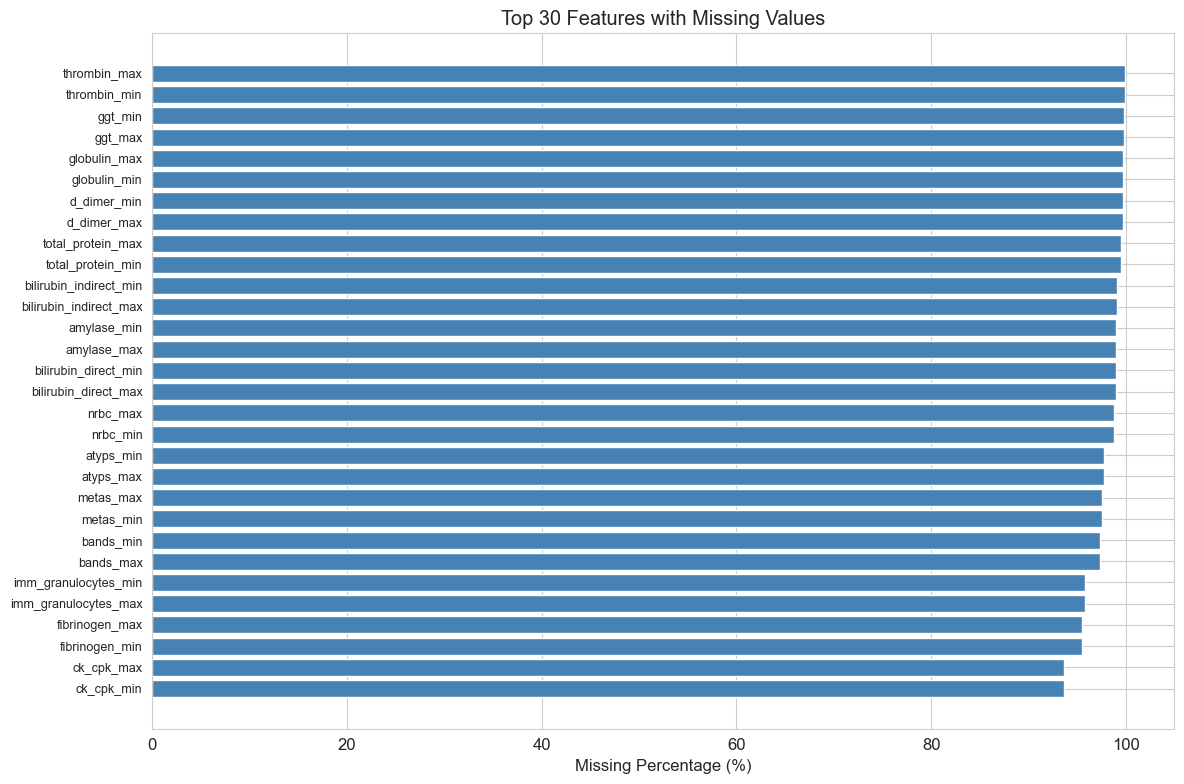

In [4]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Features with missing values: {len(missing_df)} out of {df.shape[1]}")
print(f"\n=== Top 20 Features by Missing Percentage ===")
print(missing_df.head(20))

# Visualize missing values for features with >0% missing
fig, ax = plt.subplots(figsize=(12, 8))
missing_df_plot = missing_df.head(30)
ax.barh(range(len(missing_df_plot)), missing_df_plot['Missing %'], color='steelblue')
ax.set_yticks(range(len(missing_df_plot)))
ax.set_yticklabels(missing_df_plot.index, fontsize=9)
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Top 30 Features with Missing Values')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

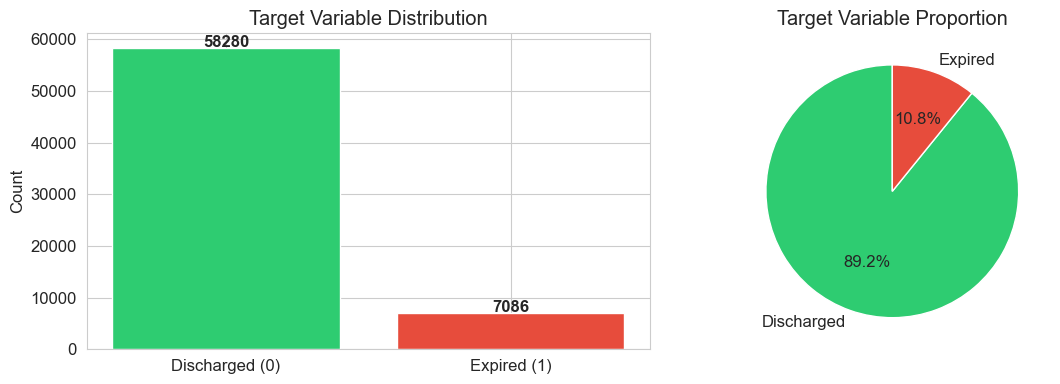

In [5]:
# Target variable distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
counts = df['hospital_expire_flag'].value_counts()
axes[0].bar(['Discharged (0)', 'Expired (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Discharged', 'Expired'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Target Variable Proportion')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

### 3.1 Remove Data Leakage Variables and Non-informative Features

According to the dataset overview, certain variables must be excluded:
- **ID variables**: `subject_id`, `hadm_id`, `stay_id` — identifiers, not predictive features
- **Data leakage variables**: `deathtime`, `icu_death_flag` — directly reveal outcomes
- **Timestamp variables**: `intime`, `outtime` — temporal markers with limited predictive value for a static model
- **Length of stay**: `los` — known only after discharge, constitutes data leakage
- **Care unit info**: `first_careunit`, `last_careunit` — may introduce leakage as unit transfers can correlate with outcome

In [6]:
# Step 1: Remove data leakage and non-informative variables
leakage_cols = ['subject_id', 'hadm_id', 'stay_id',  # IDs
                'deathtime', 'icu_death_flag',          # Direct leakage
                'intime', 'outtime',                     # Timestamps
                'los',                                    # Length of stay (known only after discharge)
                'first_careunit', 'last_careunit'         # Care unit info (potential leakage)
               ]

df_clean = df.drop(columns=leakage_cols, errors='ignore')
print(f"Original features: {df.shape[1]}")
print(f"After removing leakage/IDs: {df_clean.shape[1]}")
print(f"Removed columns: {leakage_cols}")

Original features: 140
After removing leakage/IDs: 130
Removed columns: ['subject_id', 'hadm_id', 'stay_id', 'deathtime', 'icu_death_flag', 'intime', 'outtime', 'los', 'first_careunit', 'last_careunit']


### 3.2 Handle Categorical Variables

The dataset contains categorical variables (`insurance`, `language`, `race`, `marital_status`, `gender`) that require encoding for use in machine learning models.

In [7]:
# Identify categorical and numerical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=['number']).columns.tolist()
numerical_cols.remove('hospital_expire_flag')  # Remove target from feature list

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns: {len(numerical_cols)}")

# Examine categorical variable values
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())

Categorical columns (5): ['insurance', 'language', 'race', 'marital_status', 'gender']

Numerical columns: 124

--- insurance ---
insurance
Medicare     34464
Private      18447
Medicaid      9353
Other         1733
No charge        7
Name: count, dtype: int64

--- language ---
language
English                   59076
Spanish                    1921
Chinese                     828
Russian                     752
Portuguese                  477
Haitian                     412
Kabuverdianu                403
Other                       199
Vietnamese                  185
Italian                     135
Modern Greek (1453-)        122
Arabic                      102
Khmer                        53
Persian                      52
Korean                       51
Polish                       47
American Sign Language       42
Hindi                        35
Thai                         25
French                       21
Amharic                      20
Armenian                     16
Bengali 

In [8]:
# Encode categorical variables
# For 'race': consolidate minority groups to reduce dimensionality
df_clean['race'] = df_clean['race'].apply(lambda x: x if x in ['WHITE', 'BLACK/AFRICAN AMERICAN', 'ASIAN', 'HISPANIC/LATINO'] 
                                          else 'OTHER' if pd.notna(x) else x)

# For 'gender': binary encoding (M=1, F=0)
df_clean['gender'] = df_clean['gender'].map({'M': 1, 'F': 0})

# One-Hot Encoding for remaining categorical variables
df_encoded = pd.get_dummies(df_clean, columns=['insurance', 'language', 'race', 'marital_status'], 
                            drop_first=True, dtype=int)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nNew columns from encoding:")
new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(new_cols)

Shape after encoding: (65366, 160)

New columns from encoding:
['insurance_Medicare', 'insurance_No charge', 'insurance_Other', 'insurance_Private', 'language_Amharic', 'language_Arabic', 'language_Armenian', 'language_Bengali', 'language_Chinese', 'language_English', 'language_French', 'language_Haitian', 'language_Hindi', 'language_Italian', 'language_Japanese', 'language_Kabuverdianu', 'language_Khmer', 'language_Korean', 'language_Modern Greek (1453-)', 'language_Other', 'language_Persian', 'language_Polish', 'language_Portuguese', 'language_Russian', 'language_Somali', 'language_Spanish', 'language_Thai', 'language_Vietnamese', 'race_BLACK/AFRICAN AMERICAN', 'race_OTHER', 'race_WHITE', 'marital_status_MARRIED', 'marital_status_SINGLE', 'marital_status_WIDOWED']


### 3.3 Handle Missing Values

**Missing Data Mechanism Analysis:**

In clinical databases such as MIMIC-IV, missing data rarely occurs completely at random (MCAR). Instead, most missingness follows a **Missing At Random (MAR)** or **Missing Not At Random (MNAR)** pattern. For instance, a vital sign measurement may be missing because the patient was clinically stable and the nurse judged frequent monitoring unnecessary (MAR — missingness depends on observed clinical status). Alternatively, an extremely ill patient might be too unstable for certain procedures, leading to MNAR missingness.

**Imputation Strategy & Rationale:**
- Features with **>50% missing** values are **dropped**: when more than half the observations are absent, any imputation would introduce excessive noise and unreliable synthetic values.
- Remaining numerical features are imputed using the **median**. Vital signs and lab values often exhibit right-skewed distributions with physiological outliers; the median is robust to these outliers, unlike mean imputation which would be pulled toward extreme values.
- Categorical/binary features are imputed with the **mode** (most frequent category).

**Why not more advanced methods?** Multiple Imputation (MICE) or KNN imputation would better preserve covariance structure, but they assume reliable inter-feature relationships and become computationally expensive with 65K observations × 140 features. Given that the features with heaviest missingness were already dropped, median imputation on the remaining low-missingness features is a pragmatic choice that introduces minimal bias.

In [9]:
# Drop features with >50% missing values
missing_pct_encoded = (df_encoded.isnull().sum() / len(df_encoded) * 100)
high_missing_cols = missing_pct_encoded[missing_pct_encoded > 50].index.tolist()
print(f"Features with >50% missing (to be dropped): {len(high_missing_cols)}")
print(f"Columns: {high_missing_cols}")

df_encoded = df_encoded.drop(columns=high_missing_cols)
print(f"\nShape after dropping high-missing features: {df_encoded.shape}")

# Separate target and features
y = df_encoded['hospital_expire_flag']
X = df_encoded.drop(columns=['hospital_expire_flag'])

# Impute remaining missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print(f"\nRemaining missing values after imputation: {X_imputed.isnull().sum().sum()}")
print(f"Final feature matrix shape: {X_imputed.shape}")

Features with >50% missing (to be dropped): 88
Columns: ['hematocrit_min', 'hematocrit_max', 'hemoglobin_min', 'hemoglobin_max', 'platelets_min', 'platelets_max', 'wbc_min', 'wbc_max', 'albumin_min', 'albumin_max', 'globulin_min', 'globulin_max', 'total_protein_min', 'total_protein_max', 'aniongap_min', 'aniongap_max', 'bicarbonate_min', 'bicarbonate_max', 'bun_min', 'bun_max', 'calcium_min', 'calcium_max', 'chloride_min', 'chloride_max', 'creatinine_min', 'creatinine_max', 'sodium_min', 'sodium_max', 'potassium_min', 'potassium_max', 'abs_basophils_min', 'abs_basophils_max', 'abs_eosinophils_min', 'abs_eosinophils_max', 'abs_lymphocytes_min', 'abs_lymphocytes_max', 'abs_monocytes_min', 'abs_monocytes_max', 'abs_neutrophils_min', 'abs_neutrophils_max', 'atyps_min', 'atyps_max', 'bands_min', 'bands_max', 'imm_granulocytes_min', 'imm_granulocytes_max', 'metas_min', 'metas_max', 'nrbc_min', 'nrbc_max', 'd_dimer_min', 'd_dimer_max', 'fibrinogen_min', 'fibrinogen_max', 'thrombin_min', 'thro

### 3.4 Feature Engineering — Variability & Instability Proxies

Since the dataset contains only **static aggregations** (min, max, mean) rather than raw time-series, we cannot compute temporal trends directly (e.g., "blood pressure declining over the past 6 hours"). However, we can derive **clinically meaningful proxy features** from existing columns:

1. **Range (max − min):** Captures **physiological instability** — a patient whose heart rate swings from 60 to 150 is in a very different state from one who stays between 70 and 80. High vital sign variability is a well-established predictor of ICU mortality.
2. **Coefficient of Variation (range / mean):** Normalises the range by the patient's baseline level, making variability comparable across patients with different baseline vital signs.
3. **Mean Deviation from Normal (|mean − reference|):** Captures how far each vital sign is from physiological norms, reflecting chronic derangement.

These features are particularly valuable because raw min/max/mean values may mask the **dynamic instability** that often precedes clinical deterioration.

In [10]:
# ============================================================
# Feature Engineering: Variability & Instability Proxies
# ============================================================

# Vital signs with min/max/mean triplets
triplet_vitals = {
    'heart_rate': {'normal': 80},
    'sbp':        {'normal': 120},
    'dbp':        {'normal': 80},
    'mbp':        {'normal': 93},
    'resp_rate':  {'normal': 16},
    'spo2':       {'normal': 97},
    'temperature':{'normal': 37.0},
    'glucose':    {'normal': 100},
}

# Lab values with min/max pairs (no mean) — still useful for range
pair_labs = {
    'creatinine':   {'normal': 1.0},
    'bun':          {'normal': 15},
    'hemoglobin':   {'normal': 13.5},
    'platelets':    {'normal': 250},
    'wbc':          {'normal': 7.5},
    'sodium':       {'normal': 140},
    'potassium':    {'normal': 4.0},
    'bicarbonate':  {'normal': 24},
    'bilirubin_total': {'normal': 0.7},
    'inr':          {'normal': 1.0},
}

new_features = {}
n_before = X_imputed.shape[1]

# --- Triplet vitals: range, CV, deviation from normal ---
for vital, info in triplet_vitals.items():
    col_min = f'{vital}_min'
    col_max = f'{vital}_max'
    col_mean = f'{vital}_mean'
    if col_min in X_imputed.columns and col_max in X_imputed.columns:
        # Range = instability
        new_features[f'{vital}_range'] = X_imputed[col_max] - X_imputed[col_min]
        
        # Coefficient of Variation (range / mean) — normalised instability
        if col_mean in X_imputed.columns:
            mean_vals = X_imputed[col_mean].replace(0, np.nan)
            new_features[f'{vital}_cv'] = (X_imputed[col_max] - X_imputed[col_min]) / mean_vals
            
            # Deviation from physiological normal
            new_features[f'{vital}_dev_from_normal'] = np.abs(X_imputed[col_mean] - info['normal'])

# --- Lab pairs: range only ---
for lab, info in pair_labs.items():
    col_min = f'{lab}_min'
    col_max = f'{lab}_max'
    if col_min in X_imputed.columns and col_max in X_imputed.columns:
        new_features[f'{lab}_range'] = X_imputed[col_max] - X_imputed[col_min]

# Add all new features to X_imputed
new_features_df = pd.DataFrame(new_features, index=X_imputed.index)
# Fill any NaN from division by zero
new_features_df = new_features_df.fillna(0)
X_imputed = pd.concat([X_imputed, new_features_df], axis=1)

n_after = X_imputed.shape[1]
print(f"Feature engineering: {n_before} → {n_after} features (+{n_after - n_before} new)")
print(f"\nNew features created:")
for feat_name in sorted(new_features.keys()):
    print(f"  {feat_name}")

# Quick check: are new features correlated with mortality?
print(f"\n--- Top 15 new features by |correlation with mortality| ---")
new_corr = new_features_df.corrwith(y).abs().sort_values(ascending=False)
for feat_name, corr_val in new_corr.head(15).items():
    print(f"  {feat_name}: {corr_val:.4f}")

Feature engineering: 71 → 95 features (+24 new)

New features created:
  dbp_cv
  dbp_dev_from_normal
  dbp_range
  glucose_cv
  glucose_dev_from_normal
  glucose_range
  heart_rate_cv
  heart_rate_dev_from_normal
  heart_rate_range
  mbp_cv
  mbp_dev_from_normal
  mbp_range
  resp_rate_cv
  resp_rate_dev_from_normal
  resp_rate_range
  sbp_cv
  sbp_dev_from_normal
  sbp_range
  spo2_cv
  spo2_dev_from_normal
  spo2_range
  temperature_cv
  temperature_dev_from_normal
  temperature_range

--- Top 15 new features by |correlation with mortality| ---
  resp_rate_dev_from_normal: 0.2536
  spo2_cv: 0.2448
  spo2_range: 0.2400
  spo2_dev_from_normal: 0.2383
  temperature_dev_from_normal: 0.2283
  sbp_cv: 0.2120
  mbp_dev_from_normal: 0.1568
  heart_rate_dev_from_normal: 0.1568
  mbp_cv: 0.1558
  heart_rate_range: 0.1456
  sbp_range: 0.1442
  dbp_cv: 0.1340
  sbp_dev_from_normal: 0.1299
  dbp_dev_from_normal: 0.1215
  mbp_range: 0.1101


### 3.5 Train-Test Split and Scaling

In [11]:
# Train-test split (80/20, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nTest set class distribution:\n{y_test.value_counts(normalize=True).round(4)}")

# Standardize features (important for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"\nScaling complete. Features standardized to zero mean and unit variance.")

Training set: 52292 samples
Test set: 13074 samples

Training set class distribution:
hospital_expire_flag
0    0.8916
1    0.1084
Name: proportion, dtype: float64

Test set class distribution:
hospital_expire_flag
0    0.8916
1    0.1084
Name: proportion, dtype: float64

Scaling complete. Features standardized to zero mean and unit variance.


## 4. Feature Selection Strategy (Part 2)

### Rationale

The pre-extracted MIMIC-IV dataset contains a large number of features (130+ after preprocessing). Using all features leads to several issues:
1. **Curse of dimensionality**: High-dimensional data can degrade model performance, especially for models like SVM and Logistic Regression.
2. **Overfitting**: Irrelevant or noisy features can cause models to learn noise rather than signal.
3. **Multicollinearity**: Many clinical features (e.g., `xx_min` and `xx_max` pairs) are highly correlated, which can inflate variance in linear models.
4. **Interpretability**: Fewer features lead to more interpretable and clinically actionable models.

### Proposed Strategy: A Multi-Stage Feature Selection Pipeline

The strategy combines **filter**, **embedded**, and **wrapper** methods in a progressive pipeline, ordered deliberately from **cheap-to-expensive** and **model-free-to-model-dependent**:

- **Stages 1–2 (Filters)** are applied first because they are computationally inexpensive, make no modelling assumptions, and remove the most obvious redundancies (zero-variance, high collinearity). This gives downstream methods a cleaner input.
- **Stage 3 (Statistical tests)** introduces target-awareness but remains univariate, efficiently screening individual feature–outcome associations without fitting a full model.
- **Stage 4 (Embedded / L1)** leverages a model's internal regularisation to eliminate features whose contribution does not survive penalisation. Running it after filter stages reduces the dimensionality it must handle, improving both speed and regularisation quality.
- **Stage 5 (Wrapper / RFE)** is the most computationally expensive but also the most powerful, as it considers feature interactions through iterative model re-fitting. Placing it last means it only needs to rank ~40 features instead of 71, making it tractable and more reliable.

This "funnel" design ensures each stage operates on progressively cleaner data, and the total pipeline cost remains manageable even on a dataset of 52K samples.

| Stage | Method | Purpose |
|-------|--------|---------|

| **Stage 1** | Variance Threshold | Remove near-zero-variance features |Each stage takes the output of the previous stage as input, progressively refining the feature set. This cascaded approach ensures that each subsequent method operates on a cleaner, more relevant subset of features.

| **Stage 2** | Correlation Analysis | Remove highly correlated (redundant) features |

| **Stage 3** | Univariate Statistical Tests (ANOVA F-test + Mutual Information) | Rank features by relevance to target || **Stage 5** | Recursive Feature Elimination (RFE) | Wrapper method — iterative feature pruning |
| **Stage 4** | L1 Regularization (Lasso) | Embedded method — automatic feature elimination |

### Stage 1: Variance Threshold

**How it works:** Features with very low variance contribute little discriminative information. The VarianceThreshold method removes features whose variance falls below a specified threshold. This is a computationally efficient first-pass filter.

> **Note:** As shown below, no features were removed at this stage — this is expected because the earlier preprocessing step already dropped 88 columns with >50% missing values (many of which would also exhibit near-zero variance after imputation). Stage 1 therefore serves as a **defensive safety net**: it guarantees that no degenerate features slip through without adding meaningful computational cost.

In [12]:
# Stage 1: Variance Threshold
# Apply on scaled data - remove features with near-zero variance (threshold = 0.01)
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_scaled)

# Get selected features
vt_mask = vt.get_support()
vt_selected = X_train_scaled.columns[vt_mask].tolist()
vt_removed = X_train_scaled.columns[~vt_mask].tolist()

print(f"Variance Threshold Results:")
print(f"  Features before: {X_train_scaled.shape[1]}")
print(f"  Features after:  {len(vt_selected)}")
print(f"  Features removed ({len(vt_removed)}): {vt_removed}")

Variance Threshold Results:
  Features before: 95
  Features after:  95
  Features removed (0): []


### Stage 2: Correlation Analysis

**How it works:** When two features are highly correlated (|r| > 0.85), they carry nearly redundant information. We compute the pairwise Pearson correlation matrix and, for each pair exceeding the threshold, remove the feature with lower correlation to the target variable. This reduces multicollinearity and improves model stability.

Correlation Analysis Results:
  Features before: 95
  Features after:  80
  Features removed (15): ['dbp_dev_from_normal', 'dbp_mean', 'dbp_range', 'glucose_mean', 'glucose_range', 'heart_rate_cv', 'heart_rate_min', 'mbp_max', 'mbp_range', 'resp_rate_cv', 'resp_rate_mean', 'sbp_range', 'spo2_cv', 'spo2_range', 'temperature_range']


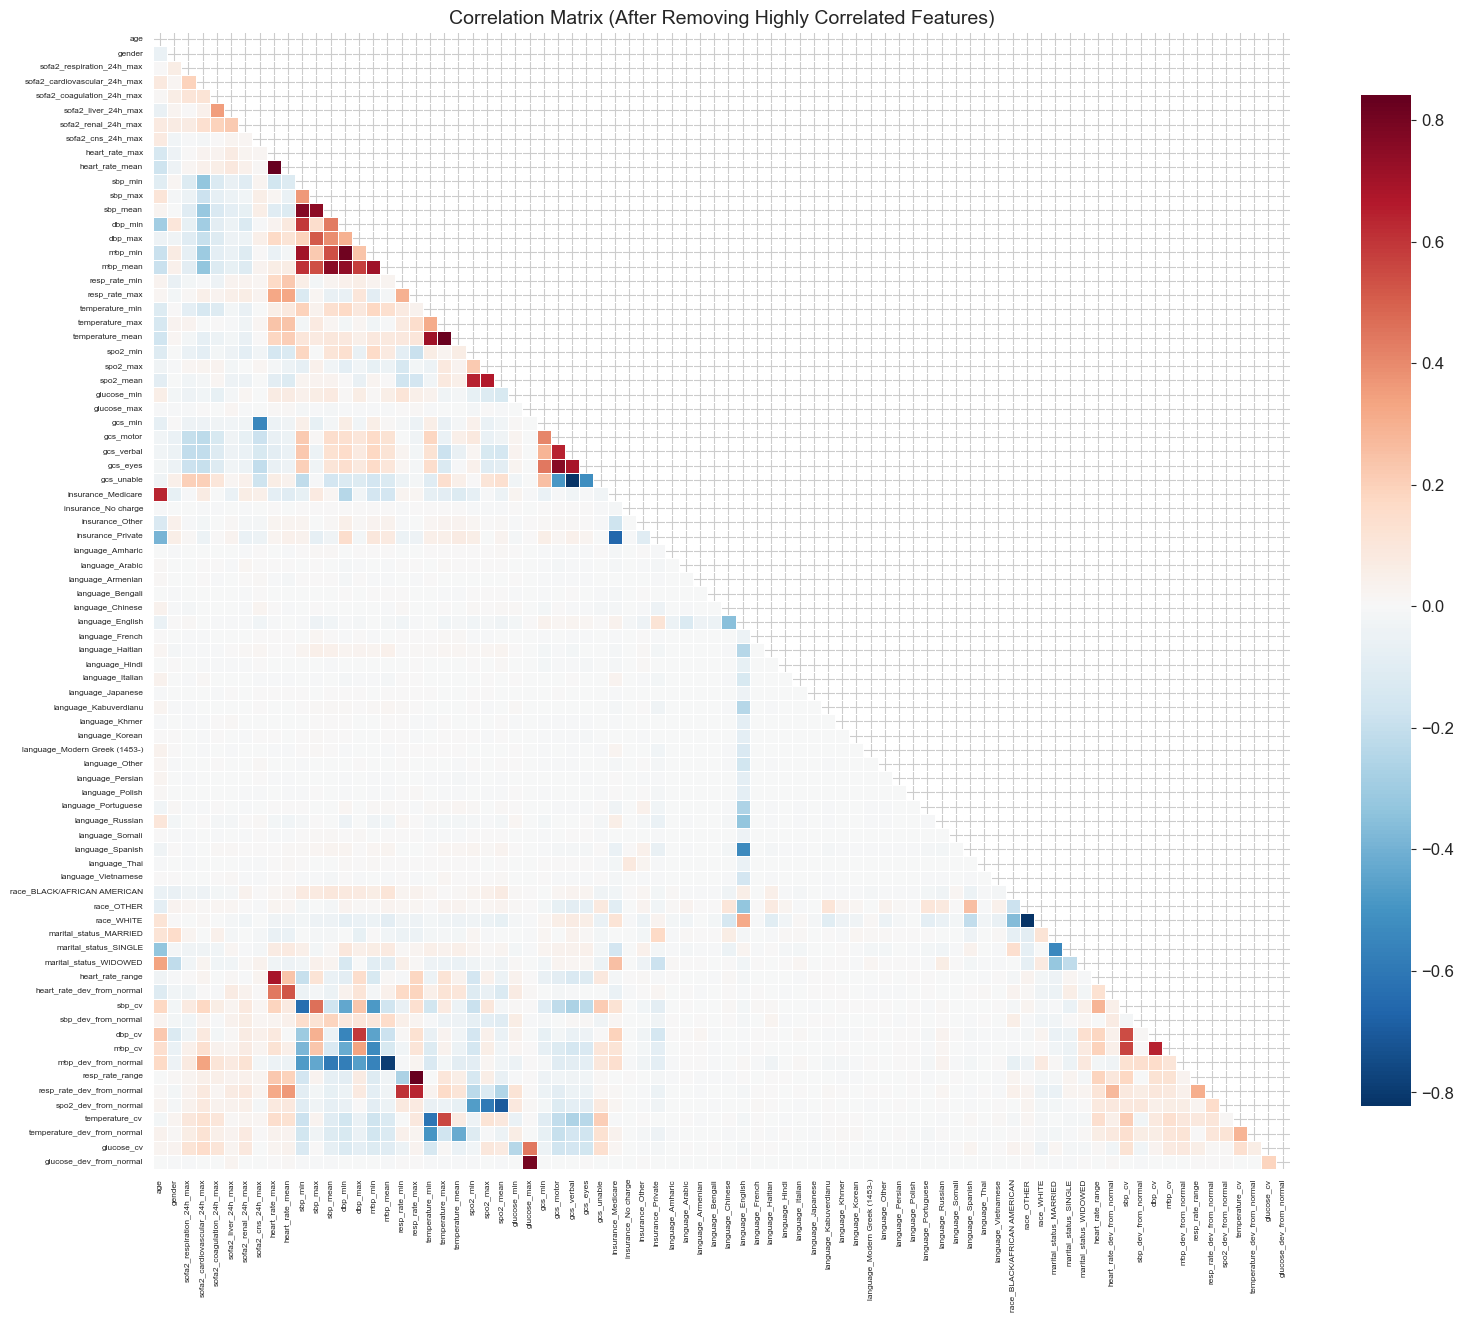

In [13]:
# Stage 2: Correlation-based feature removal
X_train_vt = X_train_scaled[vt_selected]

# Compute correlation matrix
corr_matrix = X_train_vt.corr().abs()

# Find highly correlated pairs (|r| > 0.85)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Correlation of each feature with target
target_corr = X_train_vt.corrwith(y_train).abs()

# For each pair with |r| > 0.85, mark the one with lower target correlation for removal
corr_threshold = 0.85
cols_to_remove = set()

for col in upper_tri.columns:
    high_corr_features = upper_tri.index[upper_tri[col] > corr_threshold].tolist()
    for feat in high_corr_features:
        # Remove the feature with lower correlation to target
        if target_corr.get(col, 0) >= target_corr.get(feat, 0):
            cols_to_remove.add(feat)
        else:
            cols_to_remove.add(col)

corr_selected = [c for c in vt_selected if c not in cols_to_remove]

print(f"Correlation Analysis Results:")
print(f"  Features before: {len(vt_selected)}")
print(f"  Features after:  {len(corr_selected)}")
print(f"  Features removed ({len(cols_to_remove)}): {sorted(cols_to_remove)}")

# Visualize correlation matrix of remaining features (subset for readability)
fig, ax = plt.subplots(figsize=(16, 14))
corr_plot = X_train_scaled[corr_selected].corr()
mask = np.triu(np.ones_like(corr_plot, dtype=bool))
sns.heatmap(corr_plot, mask=mask, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, ax=ax, 
            xticklabels=True, yticklabels=True,
            cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix (After Removing Highly Correlated Features)', fontsize=14)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

### Stage 3: Univariate Statistical Tests (ANOVA F-test & Mutual Information)

**How it works:**
- **ANOVA F-test** measures the linear dependency between each feature and the target. Features with high F-statistics have significantly different means across classes.
- **Mutual Information** captures any statistical dependency (including non-linear) between features and the target. 

We use both methods and retain the **union of top-ranked features** from each, capturing both linear and non-linear relationships.

ANOVA F-test: 58 features with p < 0.05
Mutual Information: 34 features with MI > 0.01

Union of ANOVA + MI: 59 features


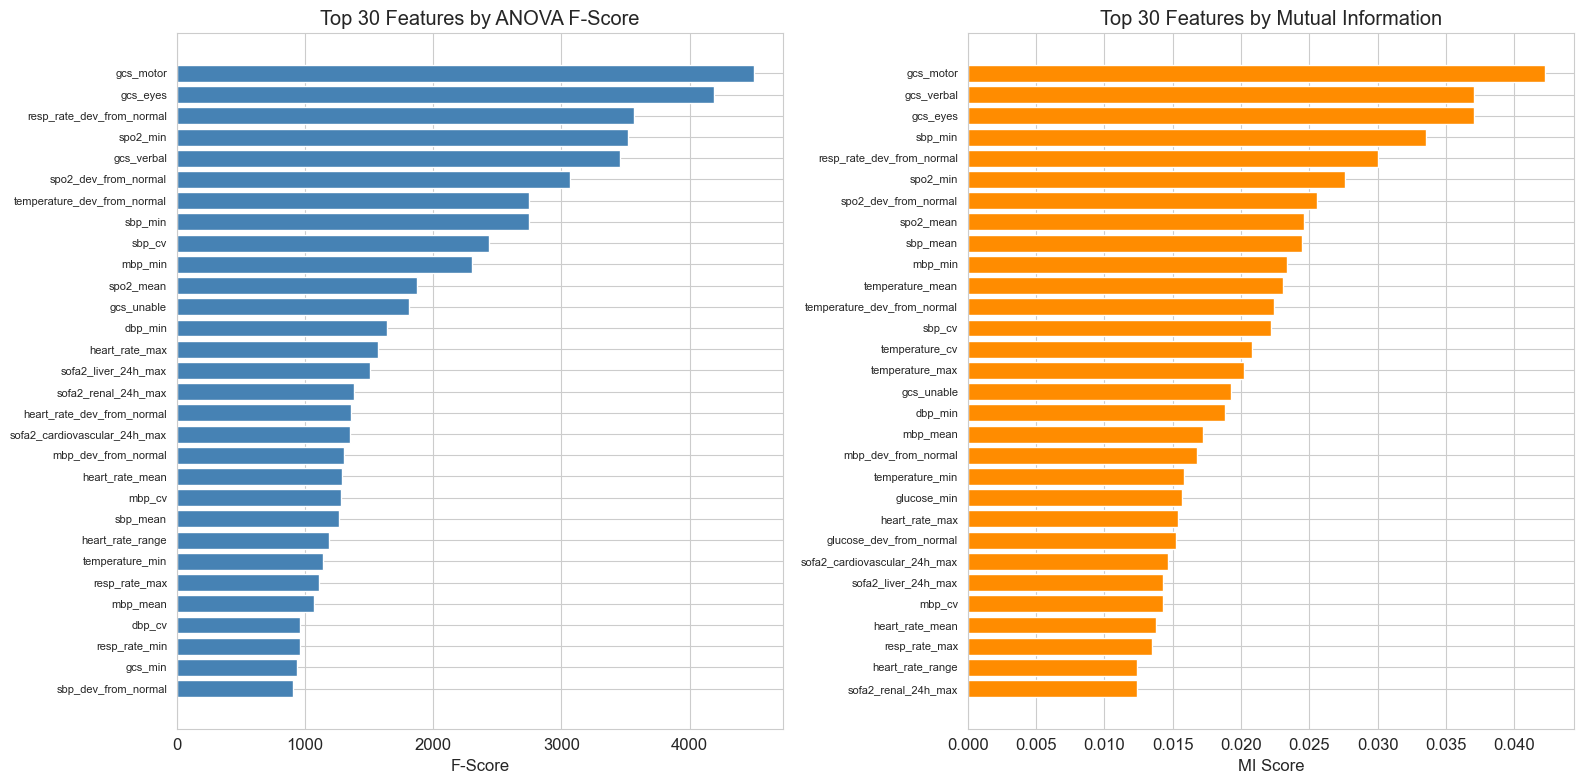

In [14]:
# Stage 3: Univariate Feature Selection
X_train_corr = X_train_scaled[corr_selected]

# 3a: ANOVA F-test
f_scores, f_pvalues = f_classif(X_train_corr, y_train)
f_score_df = pd.DataFrame({
    'Feature': corr_selected,
    'F-Score': f_scores,
    'P-Value': f_pvalues
}).sort_values('F-Score', ascending=False)

# Select features with p-value < 0.05
anova_selected = f_score_df[f_score_df['P-Value'] < 0.05]['Feature'].tolist()

print(f"ANOVA F-test: {len(anova_selected)} features with p < 0.05")

# 3b: Mutual Information
mi_scores = mutual_info_classif(X_train_corr, y_train, random_state=42)
mi_df = pd.DataFrame({
    'Feature': corr_selected,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

# Select top features with MI > 0.01
mi_selected = mi_df[mi_df['MI Score'] > 0.01]['Feature'].tolist()
print(f"Mutual Information: {len(mi_selected)} features with MI > 0.01")

# Union of both methods
univariate_selected = list(set(anova_selected) | set(mi_selected))
print(f"\nUnion of ANOVA + MI: {len(univariate_selected)} features")

# Visualize top 30 features by both metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_n = 30
f_top = f_score_df.head(top_n)
axes[0].barh(range(len(f_top)), f_top['F-Score'], color='steelblue')
axes[0].set_yticks(range(len(f_top)))
axes[0].set_yticklabels(f_top['Feature'], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title(f'Top {top_n} Features by ANOVA F-Score')
axes[0].set_xlabel('F-Score')

mi_top = mi_df.head(top_n)
axes[1].barh(range(len(mi_top)), mi_top['MI Score'], color='darkorange')
axes[1].set_yticks(range(len(mi_top)))
axes[1].set_yticklabels(mi_top['Feature'], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title(f'Top {top_n} Features by Mutual Information')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

### Stage 4: L1 Regularization (Lasso-based Logistic Regression)

**How it works:** L1 regularization (Lasso) adds a penalty proportional to the absolute values of the coefficients. During optimization, this naturally drives irrelevant feature coefficients to exactly zero, effectively performing automatic feature selection. Features with non-zero coefficients are considered important. This is an **embedded** method as feature selection occurs during model training.

L1 Regularization Results:
  Features before: 59
  Features with non-zero coefficients: 53
  Features eliminated: 6


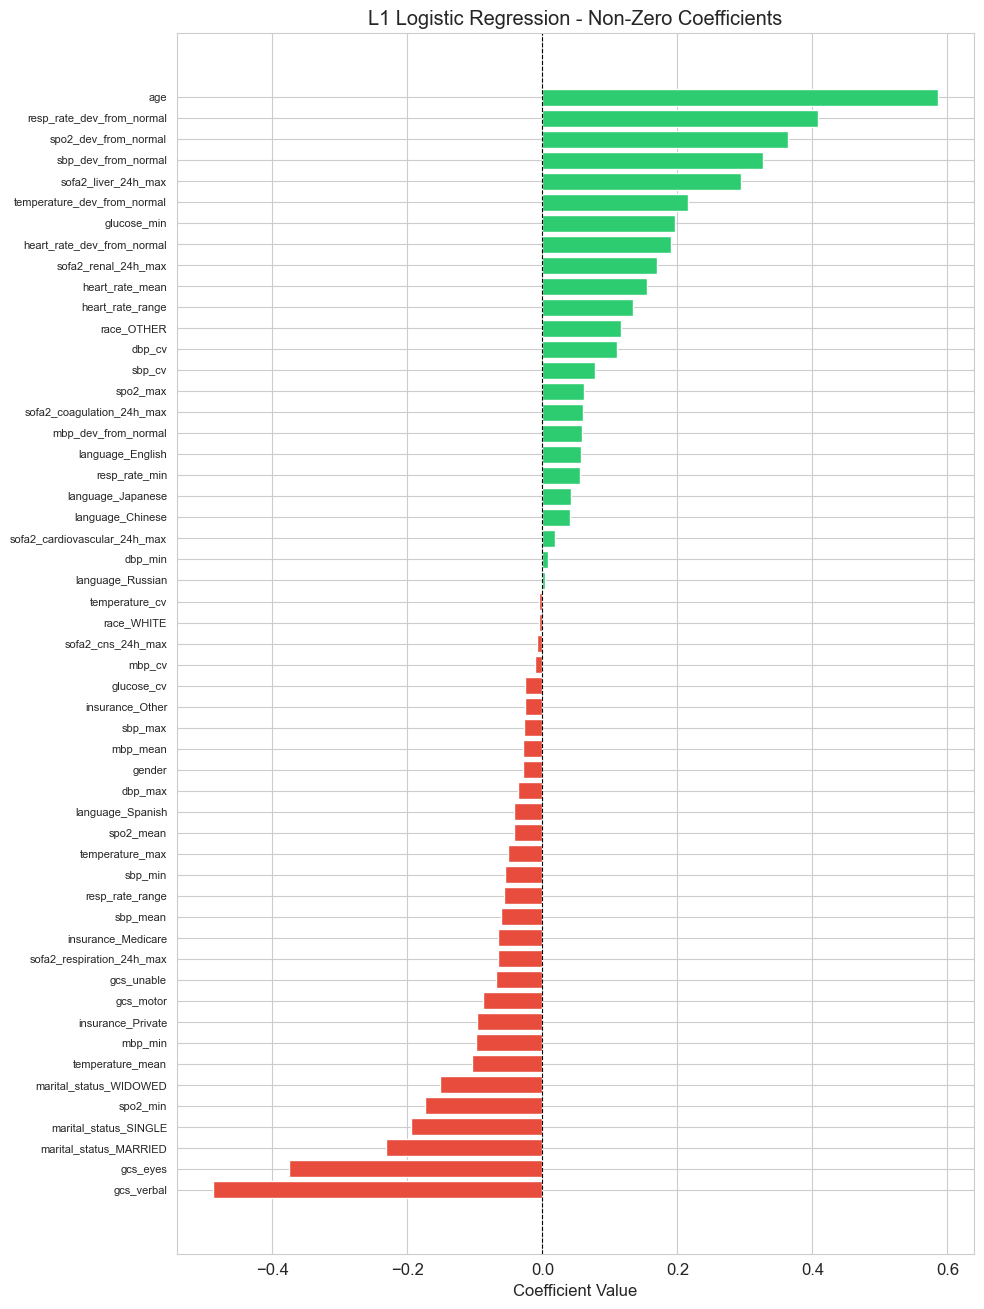

In [15]:
# Stage 4: L1 Regularization (Lasso Logistic Regression)
X_train_uni = X_train_scaled[univariate_selected]

lasso_lr = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=5000, random_state=42)
lasso_lr.fit(X_train_uni, y_train)

# Get features with non-zero coefficients
lasso_coef = pd.Series(lasso_lr.coef_[0], index=univariate_selected)
lasso_selected = lasso_coef[lasso_coef != 0].index.tolist()

print(f"L1 Regularization Results:")
print(f"  Features before: {len(univariate_selected)}")
print(f"  Features with non-zero coefficients: {len(lasso_selected)}")
print(f"  Features eliminated: {len(univariate_selected) - len(lasso_selected)}")

# Visualize Lasso coefficients
lasso_nonzero = lasso_coef[lasso_coef != 0].sort_values()
fig, ax = plt.subplots(figsize=(10, max(6, len(lasso_nonzero) * 0.25)))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in lasso_nonzero.values]
ax.barh(range(len(lasso_nonzero)), lasso_nonzero.values, color=colors)
ax.set_yticks(range(len(lasso_nonzero)))
ax.set_yticklabels(lasso_nonzero.index, fontsize=8)
ax.set_xlabel('Coefficient Value')
ax.set_title('L1 Logistic Regression - Non-Zero Coefficients')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

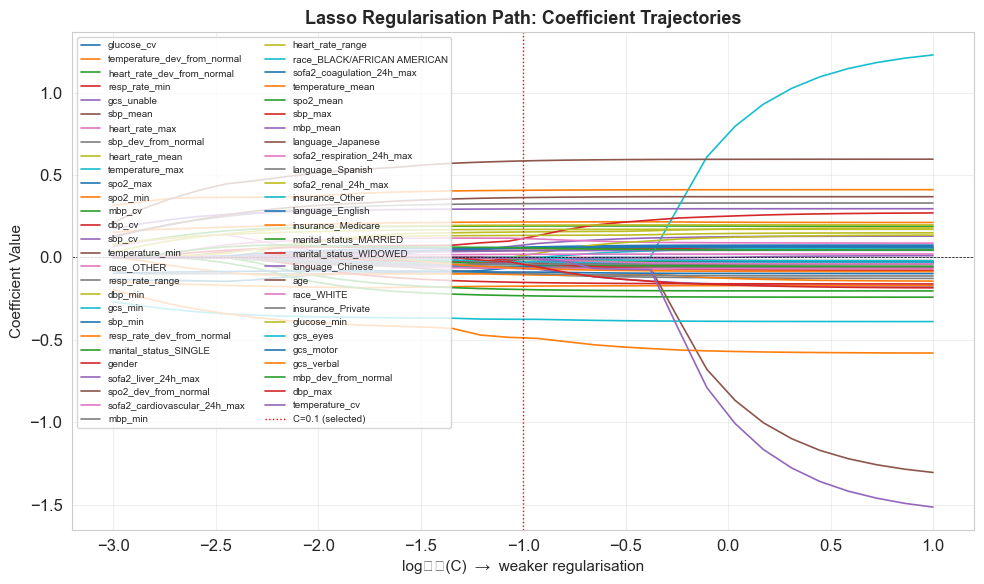

At C=0.1: 52 features have non-zero coefficients out of 59


In [16]:
# Lasso Regularization Path: how coefficients shrink with increasing penalty
from sklearn.linear_model import LogisticRegression as LR_path
import warnings
warnings.filterwarnings('ignore')

C_values = np.logspace(-3, 1, 30)
coef_paths = {feat: [] for feat in univariate_selected}

for C in C_values:
    lr_temp = LR_path(penalty='l1', solver='saga', C=C, max_iter=5000, random_state=42)
    lr_temp.fit(X_train_scaled[univariate_selected], y_train)
    for i, feat in enumerate(univariate_selected):
        coef_paths[feat].append(lr_temp.coef_[0][i])

fig, ax = plt.subplots(figsize=(10, 6))
for feat in univariate_selected:
    vals = coef_paths[feat]
    if max(abs(v) for v in vals) > 0.02:  # only plot features with visible coefficients
        ax.plot(np.log10(C_values), vals, linewidth=1.2, label=feat)
    else:
        ax.plot(np.log10(C_values), vals, linewidth=0.5, alpha=0.3, color='grey')

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(x=np.log10(0.1), color='red', linestyle=':', linewidth=1, label='C=0.1 (selected)')
ax.set_xlabel('log₁₀(C)  →  weaker regularisation', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('Lasso Regularisation Path: Coefficient Trajectories', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Count active features at selected C
n_active = sum(1 for v in coef_paths.values() if abs(v[list(C_values).index(min(C_values, key=lambda c: abs(c - 0.1)))]) > 1e-10)
print(f"At C=0.1: {n_active} features have non-zero coefficients out of {len(univariate_selected)}")
warnings.filterwarnings('default')

### Stage 5: Recursive Feature Elimination (RFE)

**How it works:** RFE is a **wrapper** method that iteratively trains a model, ranks features by importance, and removes the least important feature(s) at each step. This process repeats until the desired number of features remains. We use a Decision Tree classifier as the base estimator since it provides natural feature importance rankings.

The target number of features is set to **25** based on two considerations: (1) the **events-per-variable (EPV) guideline** — with ~7,087 positive events (Expired class), retaining a maximum of ~7,087 / 10 ≈ 700 variables would satisfy the EPV ≥ 10 rule; however, for models like SVM and Decision Trees that are sensitive to the curse of dimensionality, a much more aggressive reduction is desirable. (2) **Practical interpretability** — 25 features is small enough for clinicians to review individually, yet large enough to cover the key clinical domains (vital signs, GCS, SOFA subscores, demographics). The value 25 represents roughly the square root of the post-processing feature count (√71 ≈ 8.4 × 3 domains ≈ 25), a commonly used heuristic for balancing information retention with dimensionality reduction.

In [17]:
# Stage 5: Recursive Feature Elimination (RFE) with Decision Tree
X_train_lasso = X_train_scaled[lasso_selected]

rfe_estimator = DecisionTreeClassifier(random_state=42, max_depth=10)
n_features_target = min(25, len(lasso_selected))
rfe = RFE(estimator=rfe_estimator, n_features_to_select=n_features_target, step=1)
rfe.fit(X_train_lasso, y_train)

rfe_mask = rfe.get_support()
rfe_selected = X_train_lasso.columns[rfe_mask].tolist()
rfe_ranking = pd.DataFrame({
    'Feature': lasso_selected,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print(f"RFE Results:")
print(f"  Features before: {len(lasso_selected)}")
print(f"  Features selected: {len(rfe_selected)}")
print(f"\nSelected features (ranked by RFE):")
print(rfe_ranking[rfe_ranking['Ranking'] == 1].to_string(index=False))

RFE Results:
  Features before: 53
  Features selected: 25

Selected features (ranked by RFE):
                    Feature  Ranking
temperature_dev_from_normal        1
 heart_rate_dev_from_normal        1
                   sbp_mean        1
        sbp_dev_from_normal        1
                     mbp_cv        1
                   spo2_min        1
            temperature_max        1
            heart_rate_mean        1
                    mbp_min        1
  sofa2_coagulation_24h_max        1
                   mbp_mean        1
        sofa2_liver_24h_max        1
       spo2_dev_from_normal        1
  resp_rate_dev_from_normal        1
                    sbp_min        1
                    dbp_min        1
           temperature_mean        1
                 gcs_verbal        1
        mbp_dev_from_normal        1
             temperature_cv        1
                        age        1
                   gcs_eyes        1
                glucose_min        1
        sofa2_ren

Computing RFE learning curve (this may take a moment)...


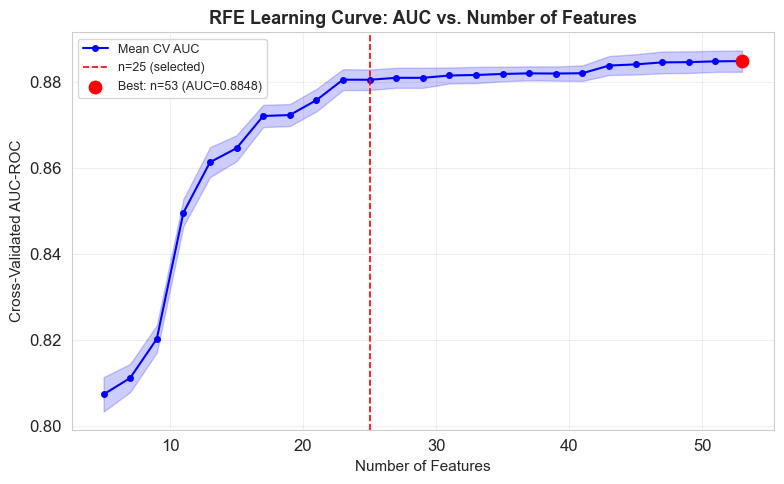


Optimal number of features: 53 (CV AUC = 0.8848)
At n=25: CV AUC = 0.8804
Performance gap: 0.43% — negligible


In [18]:
# RFE Learning Curve: how cross-validated AUC changes with number of features
from sklearn.model_selection import cross_val_score

n_range = list(range(5, len(lasso_selected)+1, 2))
if len(lasso_selected) not in n_range:
    n_range.append(len(lasso_selected))
n_range = sorted(set(n_range))

rfe_auc_scores = []
rfe_auc_stds = []

print("Computing RFE learning curve (this may take a moment)...")
for n in n_range:
    rfe_temp = RFE(estimator=DecisionTreeClassifier(random_state=42, max_depth=10),
                   n_features_to_select=n, step=1)
    rfe_temp.fit(X_train_scaled[lasso_selected], y_train)
    sel_mask = rfe_temp.get_support()
    sel_cols = [c for c, m in zip(lasso_selected, sel_mask) if m]
    
    cv_temp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        LogisticRegression(C=0.01, max_iter=5000, random_state=42, class_weight='balanced'),
        X_train_scaled[sel_cols], y_train, cv=cv_temp, scoring='roc_auc'
    )
    rfe_auc_scores.append(scores.mean())
    rfe_auc_stds.append(scores.std())

rfe_auc_scores = np.array(rfe_auc_scores)
rfe_auc_stds = np.array(rfe_auc_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_range, rfe_auc_scores, 'b-o', markersize=4, linewidth=1.5, label='Mean CV AUC')
ax.fill_between(n_range, rfe_auc_scores - rfe_auc_stds, rfe_auc_scores + rfe_auc_stds,
                alpha=0.2, color='blue')
ax.axvline(x=25, color='red', linestyle='--', linewidth=1.2, label='n=25 (selected)')

# Mark the optimal point
best_idx = np.argmax(rfe_auc_scores)
ax.scatter([n_range[best_idx]], [rfe_auc_scores[best_idx]], color='red', s=80, zorder=5,
           label=f'Best: n={n_range[best_idx]} (AUC={rfe_auc_scores[best_idx]:.4f})')

ax.set_xlabel('Number of Features', fontsize=11)
ax.set_ylabel('Cross-Validated AUC-ROC', fontsize=11)
ax.set_title('RFE Learning Curve: AUC vs. Number of Features', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal number of features: {n_range[best_idx]} (CV AUC = {rfe_auc_scores[best_idx]:.4f})")
print(f"At n=25: CV AUC = {rfe_auc_scores[n_range.index(25)]:.4f}")
auc_at_25 = rfe_auc_scores[n_range.index(25)]
auc_at_max = rfe_auc_scores[best_idx]
print(f"Performance gap: {(auc_at_max - auc_at_25)*100:.2f}% — {'negligible' if abs(auc_at_max - auc_at_25) < 0.005 else 'notable'}")

### Feature Selection Summary

The multi-stage pipeline progressively narrows the feature set: each stage takes the output of the previous as input. The final feature set is determined by the last stage (RFE), which operates on the most refined subset after all prior filtering.

FEATURE SELECTION PIPELINE SUMMARY
  Original (after preprocessing): 95 features
  Stage 1 - Variance Threshold: 95 features
  Stage 2 - Correlation Removal: 80 features
  Stage 3 - Univariate (ANOVA + MI): 59 features
  Stage 4 - L1 Regularization: 53 features
  Stage 5 - RFE: 25 features


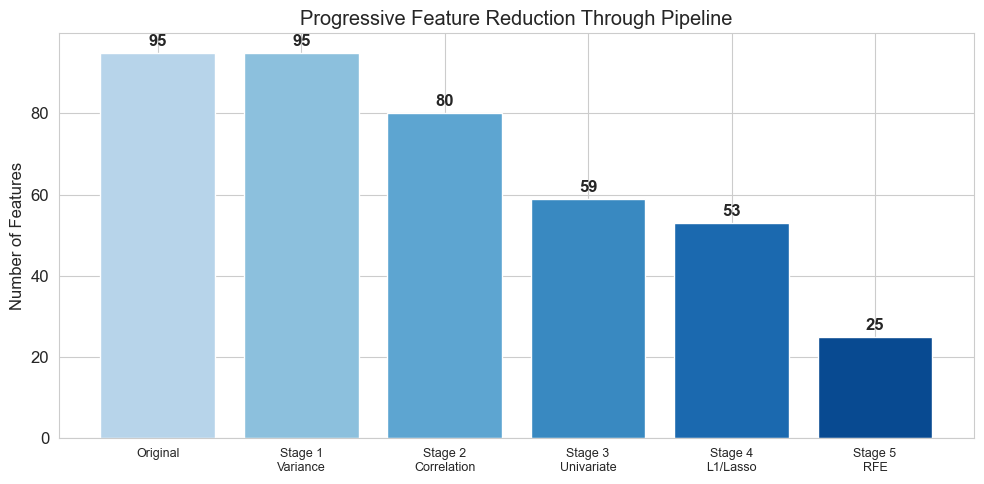


FINAL SELECTED FEATURES (25):
   1. age
   2. dbp_min
   3. gcs_eyes
   4. gcs_motor
   5. gcs_verbal
   6. glucose_min
   7. heart_rate_dev_from_normal
   8. heart_rate_mean
   9. mbp_cv
  10. mbp_dev_from_normal
  11. mbp_mean
  12. mbp_min
  13. resp_rate_dev_from_normal
  14. sbp_dev_from_normal
  15. sbp_mean
  16. sbp_min
  17. sofa2_coagulation_24h_max
  18. sofa2_liver_24h_max
  19. sofa2_renal_24h_max
  20. spo2_dev_from_normal
  21. spo2_min
  22. temperature_cv
  23. temperature_dev_from_normal
  24. temperature_max
  25. temperature_mean


In [19]:
# Feature Selection Summary
print("=" * 70)
print("FEATURE SELECTION PIPELINE SUMMARY")
print("=" * 70)

stages = {
    'Original (after preprocessing)': X_imputed.columns.tolist(),
    'Stage 1 - Variance Threshold': vt_selected,
    'Stage 2 - Correlation Removal': corr_selected,
    'Stage 3 - Univariate (ANOVA + MI)': univariate_selected,
    'Stage 4 - L1 Regularization': lasso_selected,
    'Stage 5 - RFE': rfe_selected,
}

reduction_data = []
for stage, features in stages.items():
    reduction_data.append({'Stage': stage, 'Features': len(features)})
    print(f"  {stage}: {len(features)} features")

# Visualize the progressive reduction
reduction_df = pd.DataFrame(reduction_data)
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(reduction_df)))
bars = ax.bar(range(len(reduction_df)), reduction_df['Features'], color=colors)
ax.set_xticks(range(len(reduction_df)))
ax.set_xticklabels(['Original', 'Stage 1\nVariance', 'Stage 2\nCorrelation', 
                     'Stage 3\nUnivariate', 'Stage 4\nL1/Lasso', 'Stage 5\nRFE'], 
                    fontsize=9)
ax.set_ylabel('Number of Features')
ax.set_title('Progressive Feature Reduction Through Pipeline')

# Add count labels
for bar, count in zip(bars, reduction_df['Features']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Final selected features
final_features = rfe_selected
print(f"\n{'='*70}")
print(f"FINAL SELECTED FEATURES ({len(final_features)}):")
print(f"{'='*70}")
for i, feat in enumerate(sorted(final_features), 1):
    print(f"  {i:2d}. {feat}")

## 5. Predictive Models & Performance Comparison (Part 3)

We implement the predictive models taught in the first half of the course:
1. **Logistic Regression** — baseline linear classifier
2. **Decision Tree** — non-linear tree-based classifier
3. **Support Vector Machine (SVM)** — margin-based classifier with kernel trick

### Handling Class Imbalance
The dataset is significantly imbalanced (~89% Discharged vs ~11% Expired). Without correction, models tend to predict the majority class and achieve misleadingly high accuracy while failing to identify expired patients — the clinically more critical outcome. We address this by:
- Setting `class_weight='balanced'` in all models, which automatically adjusts weights inversely proportional to class frequencies
- Prioritising **AUC-ROC**, **F1 Score**, and **Recall** over Accuracy as primary evaluation metrics

### Hyperparameter Tuning
For each model, we perform **GridSearchCV** with 5-fold stratified cross-validation to select the best hyperparameters, rather than using arbitrary defaults. This ensures fair and optimised comparison.

### Evaluation Metrics
All models are evaluated using **5-fold stratified cross-validation** on the training set and then tested on the held-out test set:
- **Accuracy** — overall correctness (can be misleading under class imbalance)
- **Precision** — positive predictive value
- **Recall (Sensitivity)** — ability to detect positive cases (expired patients, clinically critical)
- **F1 Score** — harmonic mean of precision and recall (balances precision-recall tradeoff)
- **AUC-ROC** — area under the receiver operating characteristic curve (threshold-independent)

In [20]:
# Prepare final datasets with selected features
X_train_final = X_train_scaled[final_features]
X_test_final = X_test_scaled[final_features]

print(f"Training set shape: {X_train_final.shape}")
print(f"Test set shape: {X_test_final.shape}")
print(f"Number of selected features: {len(final_features)}")

Training set shape: (52292, 25)
Test set shape: (13074, 25)
Number of selected features: 25


In [28]:
# Define evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model, perform cross-validation, and evaluate on test set."""
    
    # 5-Fold Stratified Cross-Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    # Train on full training set
  
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probability predictions (for AUC)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    # Metrics
    results = {
        'Model': model_name,
        'CV AUC (mean±std)': f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
        'CV AUC Mean': cv_scores.mean(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test Recall': recall_score(y_test, y_pred),
        'Test F1': f1_score(y_test, y_pred),
        'Test AUC': roc_auc_score(y_test, y_prob)
    }
    
    # Print classification report
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"  Cross-Validation AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy:  {results['Test Accuracy']:.4f}")
    print(f"  Test Precision: {results['Test Precision']:.4f}")
    print(f"  Test Recall:    {results['Test Recall']:.4f}")
    print(f"  Test F1 Score:  {results['Test F1']:.4f}")
    print(f"  Test AUC-ROC:   {results['Test AUC']:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Discharged', 'Expired']))
    
    return results, y_pred, y_prob

# Store results
all_results = []
all_predictions = {}
all_probabilities = {}

### 5.1 Model 1: Logistic Regression

Logistic Regression models the probability of the binary outcome using a sigmoid function. It is an efficient, interpretable, and well-suited baseline for binary classification tasks. We use L2 regularization (Ridge) to prevent overfitting, and `class_weight='balanced'` to handle class imbalance. The regularization strength `C` is tuned via GridSearchCV.

In [29]:
# Model 1: Logistic Regression with Hyperparameter Tuning
print("Tuning Logistic Regression hyperparameters...")
lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
}
lr_grid = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=5000, random_state=42, solver='lbfgs', class_weight='balanced'),
    lr_param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42), 
    scoring='roc_auc', n_jobs=-1
)
lr_grid.fit(X_train_final, y_train)
print(f"Best parameters: {lr_grid.best_params_}, Best CV AUC: {lr_grid.best_score_:.4f}")

# Evaluate with best model
lr_model = lr_grid.best_estimator_
lr_results, lr_pred, lr_prob = evaluate_model(
    lr_model, X_train_final, X_test_final, y_train, y_test, 'Logistic Regression'
)
all_results.append(lr_results)
all_predictions['Logistic Regression'] = lr_pred
all_probabilities['Logistic Regression'] = lr_prob

Tuning Logistic Regression hyperparameters...


d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set

Best parameters: {'C': 0.01}, Best CV AUC: 0.8805

  Logistic Regression
  Cross-Validation AUC: 0.8805 ± 0.0034
  Test Accuracy:  0.8007
  Test Precision: 0.3256
  Test Recall:    0.7826
  Test F1 Score:  0.4599
  Test AUC-ROC:   0.8789

Classification Report:
              precision    recall  f1-score   support

  Discharged       0.97      0.80      0.88     11657
     Expired       0.33      0.78      0.46      1417

    accuracy                           0.80     13074
   macro avg       0.65      0.79      0.67     13074
weighted avg       0.90      0.80      0.83     13074



d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### 5.2 Model 2: Decision Tree

Decision Trees partition the feature space through recursive binary splits, selecting the feature and threshold that best separates the classes at each node (using Gini impurity or information gain). They handle non-linear relationships naturally and are highly interpretable. We tune `max_depth` and `min_samples_leaf` via GridSearchCV and use `class_weight='balanced'` to handle class imbalance.

In [30]:
# Model 2: Decision Tree with Hyperparameter Tuning
print("Tuning Decision Tree hyperparameters...")
dt_param_grid = {
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_leaf': [5, 10, 20],
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, criterion='gini', class_weight='balanced'),
    dt_param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
dt_grid.fit(X_train_final, y_train)
print(f"Best parameters: {dt_grid.best_params_}, Best CV AUC: {dt_grid.best_score_:.4f}")

dt_model = dt_grid.best_estimator_
dt_results, dt_pred, dt_prob = evaluate_model(
    dt_model, X_train_final, X_test_final, y_train, y_test, 'Decision Tree'
)
all_results.append(dt_results)
all_predictions['Decision Tree'] = dt_pred
all_probabilities['Decision Tree'] = dt_prob

Tuning Decision Tree hyperparameters...
Best parameters: {'max_depth': 6, 'min_samples_leaf': 20}, Best CV AUC: 0.8456

  Decision Tree
  Cross-Validation AUC: 0.8456 ± 0.0047
  Test Accuracy:  0.7683
  Test Precision: 0.2856
  Test Recall:    0.7579
  Test F1 Score:  0.4149
  Test AUC-ROC:   0.8370

Classification Report:
              precision    recall  f1-score   support

  Discharged       0.96      0.77      0.86     11657
     Expired       0.29      0.76      0.41      1417

    accuracy                           0.77     13074
   macro avg       0.62      0.76      0.64     13074
weighted avg       0.89      0.77      0.81     13074



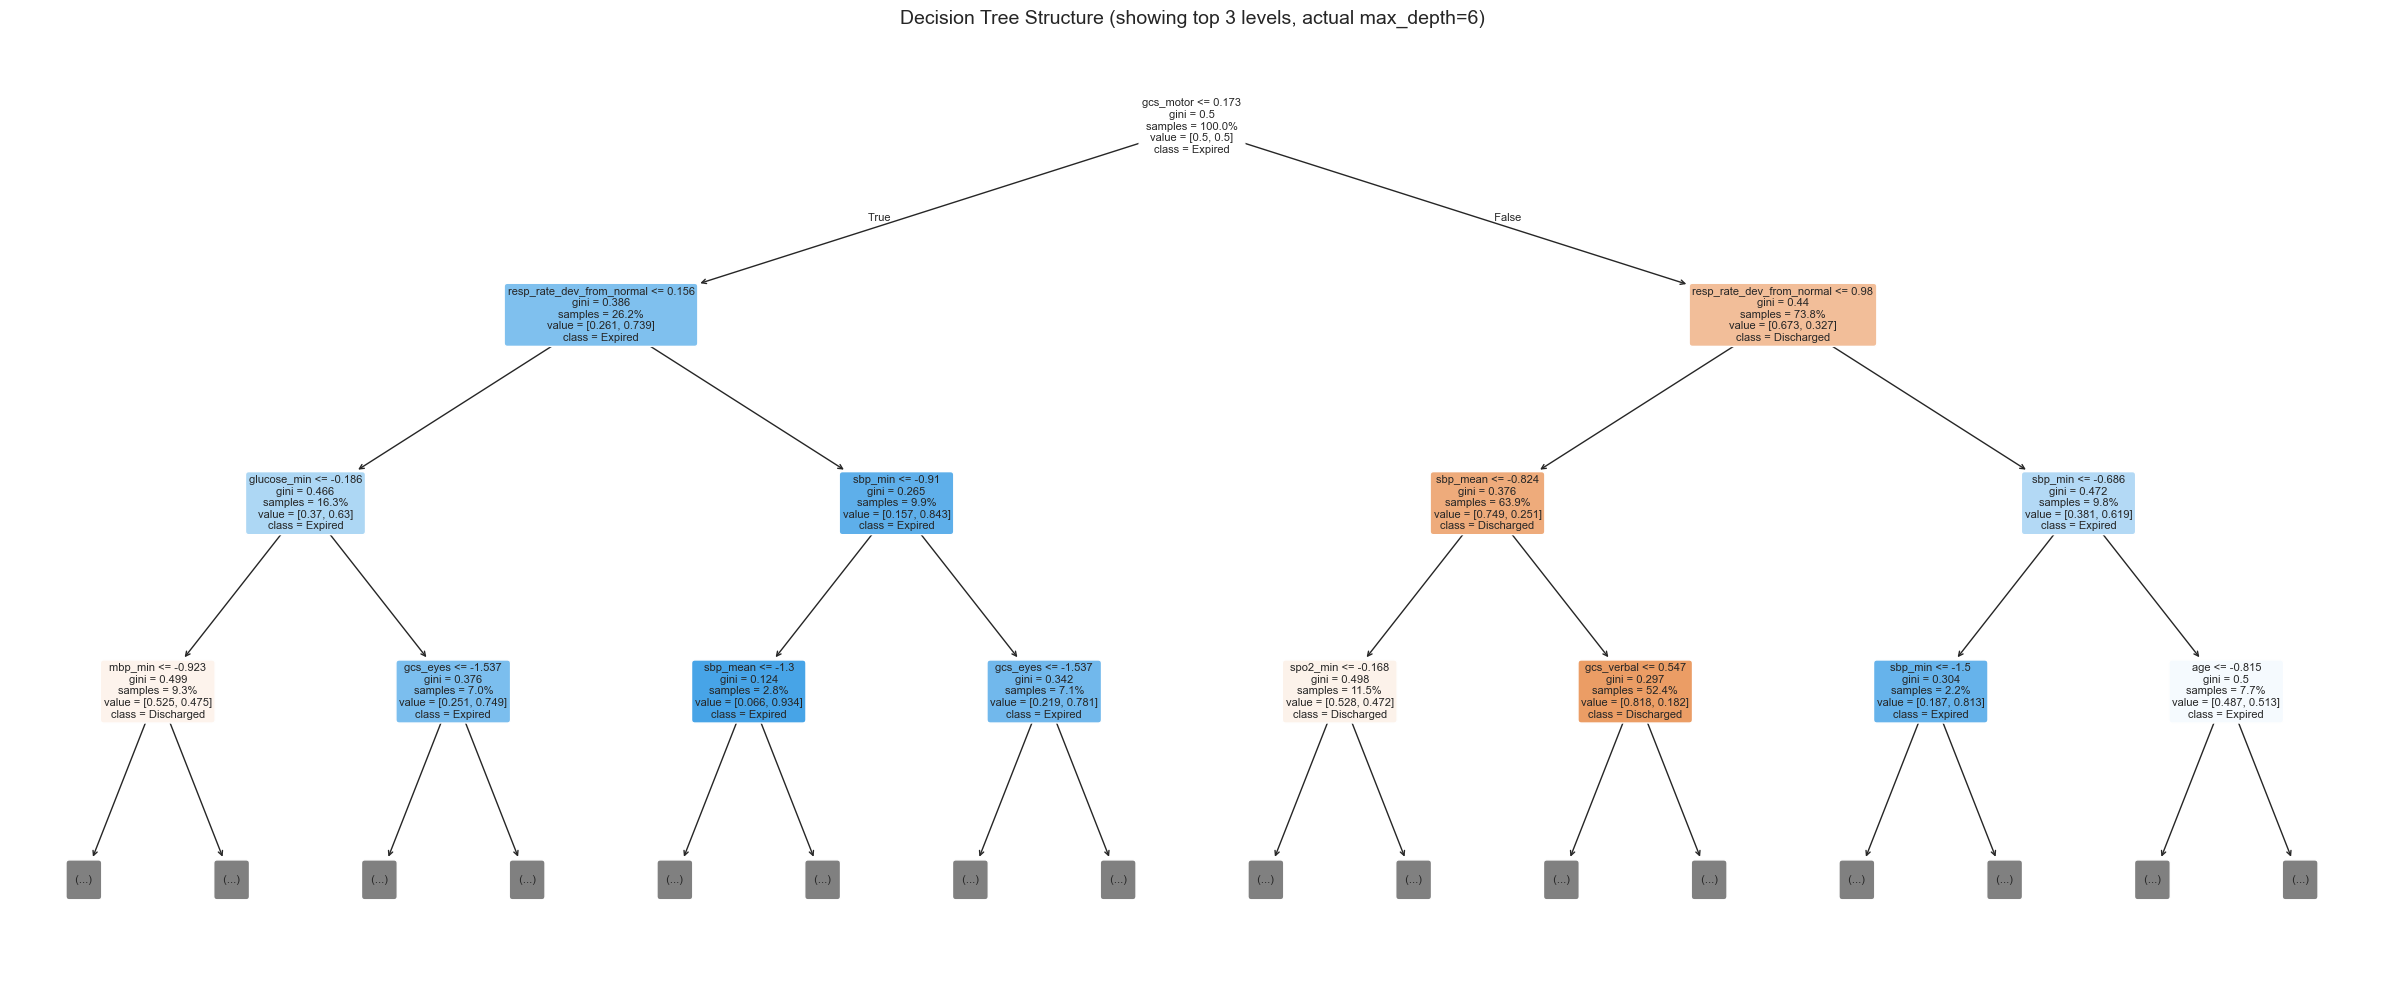

Top 10 features by Decision Tree importance:
gcs_motor                    0.414117
resp_rate_dev_from_normal    0.183370
sbp_mean                     0.072840
spo2_min                     0.051638
sbp_min                      0.048381
glucose_min                  0.041870
age                          0.035874
gcs_verbal                   0.029791
sofa2_renal_24h_max          0.024171
gcs_eyes                     0.019490


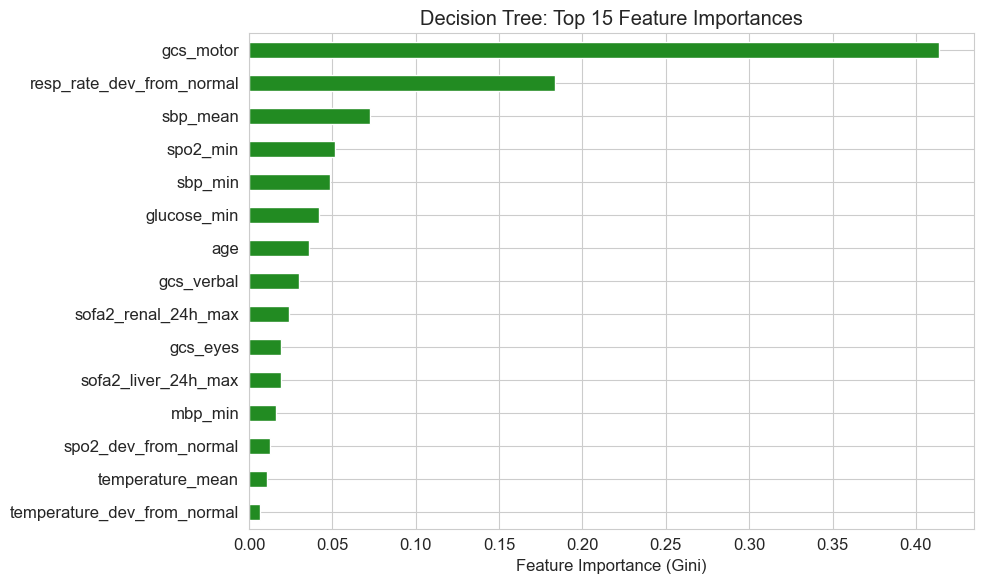

In [31]:
# Visualize the Decision Tree structure
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_model, feature_names=final_features, class_names=['Discharged', 'Expired'],
          filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax,
          proportion=True, impurity=True)
ax.set_title(f'Decision Tree Structure (showing top 3 levels, actual max_depth={dt_model.get_depth()})', fontsize=14)
plt.tight_layout()
plt.show()

# Feature importance from Decision Tree
dt_importance = pd.Series(dt_model.feature_importances_, index=final_features).sort_values(ascending=False)
print("Top 10 features by Decision Tree importance:")
print(dt_importance.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
dt_importance.head(15).plot(kind='barh', color='forestgreen', ax=ax)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree: Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3 Model 3: Support Vector Machine (SVM)

**Decision Tree Overfitting Discussion:** Before moving to SVM, it is worth reflecting on why the Decision Tree underperformed. Decision Trees are high-variance models: small changes in training data can produce entirely different tree structures. Their axis-aligned splits (one feature at a time) also limit their ability to capture diagonal or curved decision boundaries. Although we constrained depth (`max_depth=6`) and leaf size (`min_samples_leaf=20`) via GridSearchCV, these constraints trade off overfitting risk against model expressiveness — deeper trees overfit, while shallow trees underfit. The DT's CV AUC standard deviation (0.004) was higher than LR's (0.003), confirming its greater instability. This motivates using SVM, which achieves smoother, more generalizable boundaries.

**SVM Overview:** SVM finds the optimal hyperplane that maximizes the margin between classes. With the RBF (Radial Basis Function) kernel, SVM can model complex, non-linear decision boundaries by mapping features into a higher-dimensional space. It is effective in high-dimensional settings and robust to overfitting with proper regularization.

SVM with RBF kernel has $O(n^2)$ to $O(n^3)$ time complexity, making direct GridSearchCV on the full 52K training set computationally prohibitive. We therefore perform **hyperparameter tuning on a stratified 10K subsample**, then **retrain the best model on the full training set** for fair evaluation. This two-stage approach balances computational efficiency with model quality.

In [32]:
# Model 3: Support Vector Machine (SVM) with RBF Kernel
# Stage 1: GridSearchCV on stratified subsample for hyperparameter tuning
from sklearn.model_selection import train_test_split as tts_sub
X_sub, _, y_sub, _ = tts_sub(X_train_final, y_train, train_size=10000,
                              random_state=42, stratify=y_train)
print(f"Tuning SVM on stratified subsample (n={len(X_sub)})...")

svm_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 'auto'],
}
svm_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    svm_param_grid, cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
svm_grid.fit(X_sub, y_sub)
print(f"Best parameters: {svm_grid.best_params_}, Best CV AUC (subsample): {svm_grid.best_score_:.4f}")

# Stage 2: Retrain best model on FULL training set
print("Retraining best SVM on full training data...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42,
                class_weight='balanced', **svm_grid.best_params_)
svm_model.fit(X_train_final, y_train)
print("Full training complete.")

svm_results, svm_pred, svm_prob = evaluate_model(
    svm_model, X_train_final, X_test_final, y_train, y_test, 'SVM (RBF Kernel)'
)
all_results.append(svm_results)
all_predictions['SVM (RBF Kernel)'] = svm_pred
all_probabilities['SVM (RBF Kernel)'] = svm_prob

Tuning SVM on stratified subsample (n=10000)...
Best parameters: {'C': 0.1, 'gamma': 'scale'}, Best CV AUC (subsample): 0.8831
Retraining best SVM on full training data...
Full training complete.

  SVM (RBF Kernel)
  Cross-Validation AUC: 0.8941 ± 0.0042
  Test Accuracy:  0.8134
  Test Precision: 0.3470
  Test Recall:    0.8179
  Test F1 Score:  0.4873
  Test AUC-ROC:   0.8922

Classification Report:
              precision    recall  f1-score   support

  Discharged       0.97      0.81      0.89     11657
     Expired       0.35      0.82      0.49      1417

    accuracy                           0.81     13074
   macro avg       0.66      0.82      0.69     13074
weighted avg       0.91      0.81      0.84     13074



### 5.4 Control Experiment: SVM with Linear Kernel

To determine whether the performance advantage of SVM (RBF) over Logistic Regression is due to **non-linear decision boundaries** (RBF kernel effect) or simply **margin maximisation** (SVM's inherent optimisation principle), we run an additional SVM with a **linear kernel** as a control experiment. If SVM(linear) ≈ LR, the gap is attributable to non-linearity. If SVM(linear) > LR, marginalisation also contributes.

In [33]:

# Control experiment: SVM with Linear Kernel
# This isolates the effect of the RBF kernel (non-linearity) from margin maximisation
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("Training SVM with Linear Kernel (control experiment)...")
linear_svm = LinearSVC(C=0.01, class_weight='balanced', max_iter=10000, random_state=42, dual=True)
# Wrap with CalibratedClassifierCV to get probability estimates
linear_svm_calibrated = CalibratedClassifierCV(linear_svm, cv=3, method='sigmoid')
linear_svm_calibrated.fit(X_train_final, y_train)

# Evaluate
y_pred_linear = linear_svm_calibrated.predict(X_test_final)
y_prob_linear = linear_svm_calibrated.predict_proba(X_test_final)[:, 1]

cv_linear = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_linear = cross_val_score(
    CalibratedClassifierCV(LinearSVC(C=0.01, class_weight='balanced', max_iter=10000, random_state=42, dual=True), cv=3),
    X_train_final, y_train, cv=cv_linear, scoring='roc_auc'
)

auc_linear = roc_auc_score(y_test, y_prob_linear)
recall_linear = recall_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)

print(f"\n{'='*70}")
print("CONTROL EXPERIMENT: Isolating Kernel Effect")
print(f"{'='*70}")
print(f"  SVM (Linear Kernel):  CV AUC = {cv_scores_linear.mean():.4f} ± {cv_scores_linear.std():.4f},  Test AUC = {auc_linear:.4f},  Recall = {recall_linear:.4f}")
print(f"  SVM (RBF Kernel):     CV AUC = {svm_results['CV AUC Mean']:.4f},  Test AUC = {svm_results['Test AUC']:.4f},  Recall = {svm_results['Test Recall']:.4f}")
print(f"  Logistic Regression:  CV AUC = {lr_results['CV AUC Mean']:.4f},  Test AUC = {lr_results['Test AUC']:.4f},  Recall = {lr_results['Test Recall']:.4f}")
print(f"\n  AUC gap: SVM(Linear) vs LR       = {auc_linear - lr_results['Test AUC']:.4f}")
print(f"  AUC gap: SVM(RBF) vs SVM(Linear)  = {svm_results['Test AUC'] - auc_linear:.4f}")
print(f"\n  Interpretation:")
if abs(auc_linear - lr_results['Test AUC']) < 0.01:
    print(f"  → SVM(Linear) ≈ LR: The SVM(RBF) advantage is primarily from NON-LINEAR decision boundaries.")
else:
    print(f"  → SVM(Linear) > LR by {auc_linear - lr_results['Test AUC']:.3f}: Margin maximisation contributes partially.")
    print(f"  → SVM(RBF) > SVM(Linear) by {svm_results['Test AUC'] - auc_linear:.3f}: Non-linear boundaries provide additional gains.")


Training SVM with Linear Kernel (control experiment)...

CONTROL EXPERIMENT: Isolating Kernel Effect
  SVM (Linear Kernel):  CV AUC = 0.8804 ± 0.0033,  Test AUC = 0.8784,  Recall = 0.3289
  SVM (RBF Kernel):     CV AUC = 0.8941,  Test AUC = 0.8922,  Recall = 0.8179
  Logistic Regression:  CV AUC = 0.8805,  Test AUC = 0.8789,  Recall = 0.7826

  AUC gap: SVM(Linear) vs LR       = -0.0005
  AUC gap: SVM(RBF) vs SVM(Linear)  = 0.0138

  Interpretation:
  → SVM(Linear) ≈ LR: The SVM(RBF) advantage is primarily from NON-LINEAR decision boundaries.


### 5.5 Ensemble Models: Random Forest, XGBoost, and AdaBoost

To further explore the predictive landscape, we add three ensemble methods that build upon the tree-based paradigm:

- **Random Forest** aggregates many decorrelated decision trees via bagging (bootstrap aggregation) and random feature subsampling, reducing variance compared to a single tree.
- **XGBoost** (eXtreme Gradient Boosting) is a highly optimised implementation of gradient boosting that sequentially fits trees to the residuals of previous trees, with built-in regularisation (L1/L2 on leaf weights) and column subsampling.
- **AdaBoost** (Adaptive Boosting) iteratively re-weights misclassified samples so that subsequent weak learners focus on the hardest examples.

In [34]:
# Model 4: Random Forest
print("Tuning Random Forest hyperparameters...")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 15],
    'min_samples_leaf': [5, 10],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train_final, y_train)
print(f"Best parameters: {rf_grid.best_params_}, Best CV AUC: {rf_grid.best_score_:.4f}")

rf_model = rf_grid.best_estimator_
rf_results, rf_pred, rf_prob = evaluate_model(
    rf_model, X_train_final, X_test_final, y_train, y_test, 'Random Forest'
)
all_results.append(rf_results)
all_predictions['Random Forest'] = rf_pred
all_probabilities['Random Forest'] = rf_prob

Tuning Random Forest hyperparameters...
Best parameters: {'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 200}, Best CV AUC: 0.8976

  Random Forest
  Cross-Validation AUC: 0.8976 ± 0.0040
  Test Accuracy:  0.8995
  Test Precision: 0.5359
  Test Recall:    0.5427
  Test F1 Score:  0.5393
  Test AUC-ROC:   0.8914

Classification Report:
              precision    recall  f1-score   support

  Discharged       0.94      0.94      0.94     11657
     Expired       0.54      0.54      0.54      1417

    accuracy                           0.90     13074
   macro avg       0.74      0.74      0.74     13074
weighted avg       0.90      0.90      0.90     13074



In [35]:
# Model 5: XGBoost
from xgboost import XGBClassifier

# Compute scale_pos_weight for class imbalance (equivalent to class_weight='balanced')
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pw = neg_count / pos_count

print("Tuning XGBoost hyperparameters...")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pw, random_state=42, 
                  use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    xgb_param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
xgb_grid.fit(X_train_final, y_train)
print(f"Best parameters: {xgb_grid.best_params_}, Best CV AUC: {xgb_grid.best_score_:.4f}")

xgb_model = xgb_grid.best_estimator_
xgb_results, xgb_pred, xgb_prob = evaluate_model(
    xgb_model, X_train_final, X_test_final, y_train, y_test, 'XGBoost'
)
all_results.append(xgb_results)
all_predictions['XGBoost'] = xgb_pred
all_probabilities['XGBoost'] = xgb_prob

Tuning XGBoost hyperparameters...


d:\study\SPH 6004\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:18:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}, Best CV AUC: 0.9017


d:\study\SPH 6004\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:18:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\study\SPH 6004\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:18:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\study\SPH 6004\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:18:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\study\SPH 6004\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:18:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain,


  XGBoost
  Cross-Validation AUC: 0.9017 ± 0.0022
  Test Accuracy:  0.8307
  Test Precision: 0.3686
  Test Recall:    0.7890
  Test F1 Score:  0.5025
  Test AUC-ROC:   0.8984

Classification Report:
              precision    recall  f1-score   support

  Discharged       0.97      0.84      0.90     11657
     Expired       0.37      0.79      0.50      1417

    accuracy                           0.83     13074
   macro avg       0.67      0.81      0.70     13074
weighted avg       0.91      0.83      0.86     13074



In [36]:
# Model 6: AdaBoost
from sklearn.ensemble import AdaBoostClassifier

print("Tuning AdaBoost hyperparameters...")
ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
}
# Use a Decision Tree stump with class_weight='balanced' as base estimator
ada_base = DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=42)
ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=ada_base, random_state=42),
    ada_param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
ada_grid.fit(X_train_final, y_train)
print(f"Best parameters: {ada_grid.best_params_}, Best CV AUC: {ada_grid.best_score_:.4f}")

ada_model = ada_grid.best_estimator_
ada_results, ada_pred, ada_prob = evaluate_model(
    ada_model, X_train_final, X_test_final, y_train, y_test, 'AdaBoost'
)
all_results.append(ada_results)
all_predictions['AdaBoost'] = ada_pred
all_probabilities['AdaBoost'] = ada_prob

Tuning AdaBoost hyperparameters...
Best parameters: {'learning_rate': 0.1, 'n_estimators': 50}, Best CV AUC: 0.8230

  AdaBoost
  Cross-Validation AUC: 0.8230 ± 0.0055
  Test Accuracy:  0.8448
  Test Precision: 0.3561
  Test Recall:    0.5342
  Test F1 Score:  0.4273
  Test AUC-ROC:   0.8160

Classification Report:
              precision    recall  f1-score   support

  Discharged       0.94      0.88      0.91     11657
     Expired       0.36      0.53      0.43      1417

    accuracy                           0.84     13074
   macro avg       0.65      0.71      0.67     13074
weighted avg       0.88      0.84      0.86     13074



### 5.4 Model Performance Comparison

In [37]:
# Compile results into a comparison table
results_df = pd.DataFrame(all_results)
display_cols = ['Model', 'CV AUC (mean±std)', 'Test Accuracy', 'Test Precision', 
                'Test Recall', 'Test F1', 'Test AUC']
results_display = results_df[display_cols].copy()

# Format numeric columns
for col in ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test AUC']:
    results_display[col] = results_display[col].apply(lambda x: f"{x:.4f}")

print("\n" + "=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)
print(results_display.to_string(index=False))
print("=" * 90)


MODEL PERFORMANCE COMPARISON
              Model CV AUC (mean±std) Test Accuracy Test Precision Test Recall Test F1 Test AUC
Logistic Regression   0.8805 ± 0.0034        0.8007         0.3256      0.7826  0.4599   0.8789
      Decision Tree   0.8456 ± 0.0047        0.7683         0.2856      0.7579  0.4149   0.8370
   SVM (RBF Kernel)   0.8941 ± 0.0042        0.8134         0.3470      0.8179  0.4873   0.8922
      Random Forest   0.8976 ± 0.0040        0.8995         0.5359      0.5427  0.5393   0.8914
            XGBoost   0.9017 ± 0.0022        0.8307         0.3686      0.7890  0.5025   0.8984
           AdaBoost   0.8230 ± 0.0055        0.8448         0.3561      0.5342  0.4273   0.8160


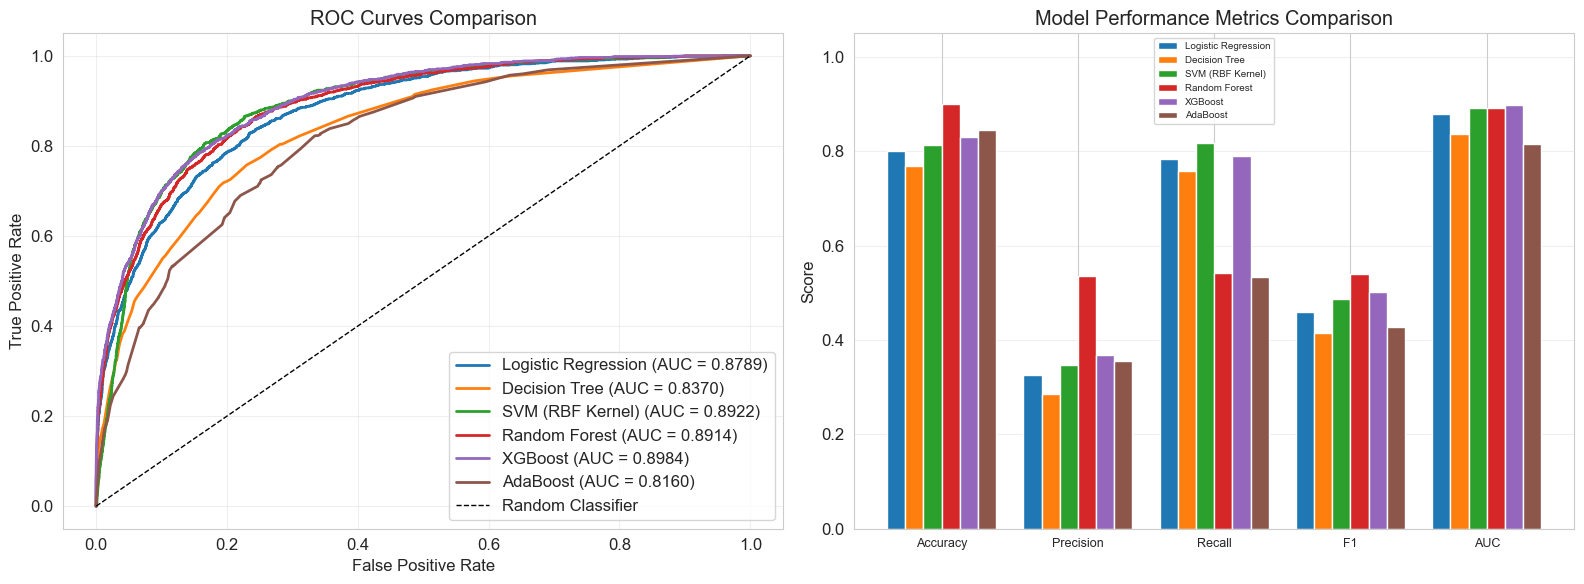

In [38]:
# ROC Curves Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: ROC Curves
for model_name, y_prob in all_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves Comparison')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Bar chart comparison of metrics
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test AUC']
x = np.arange(len(metrics))
n_bars = len(all_results)
width = 0.8 / n_bars

for i, result in enumerate(all_results):
    values = [result[m] for m in metrics]
    axes[1].bar(x + i * width - 0.4 + width/2, values, width, label=result['Model'])

axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Metrics Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'], fontsize=9)
axes[1].legend(fontsize=7)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

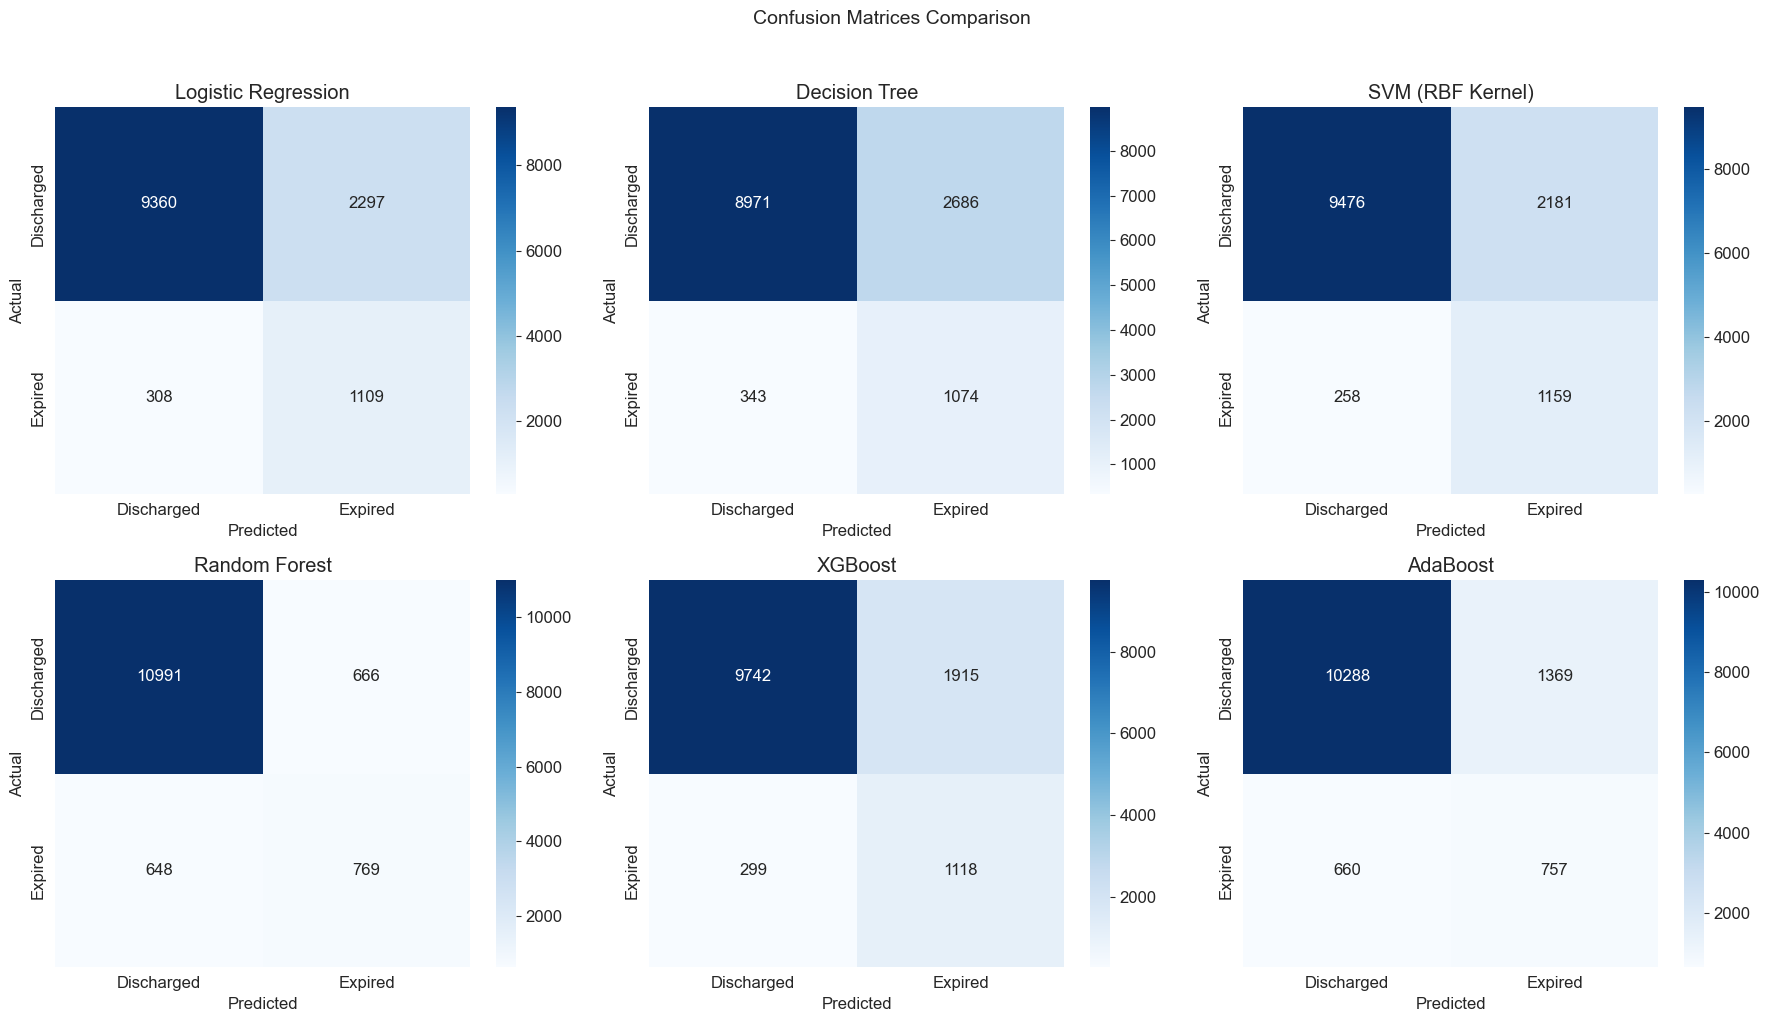

In [39]:
# Confusion Matrices
n_models = len(all_predictions)
ncols_cm = min(n_models, 3)
nrows_cm = (n_models + ncols_cm - 1) // ncols_cm
fig, axes = plt.subplots(nrows_cm, ncols_cm, figsize=(6 * ncols_cm, 5 * nrows_cm))
axes_flat = np.array(axes).flatten() if n_models > 1 else [axes]

for idx, (model_name, y_pred) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=['Discharged', 'Expired'],
                yticklabels=['Discharged', 'Expired'])
    axes_flat[idx].set_title(f'{model_name}')
    axes_flat[idx].set_ylabel('Actual')
    axes_flat[idx].set_xlabel('Predicted')

# Hide unused subplots
for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Confusion Matrices Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Performance with All Features vs. Selected Features

To demonstrate the effectiveness of our feature selection strategy, we compare model performance using **all features** versus the **selected features**.

Comparison: All Features vs. Selected Features


d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set

              Model  All Features AUC  Selected Features AUC  All Features F1  Selected Features F1  All Features CV-AUC  Selected Features CV-AUC Feature Reduction
Logistic Regression          0.885326               0.878906         0.470391              0.460104             0.885215                  0.880451           95 → 25
      Decision Tree          0.829367               0.840253         0.411193              0.421639             0.825569                  0.835305           95 → 25


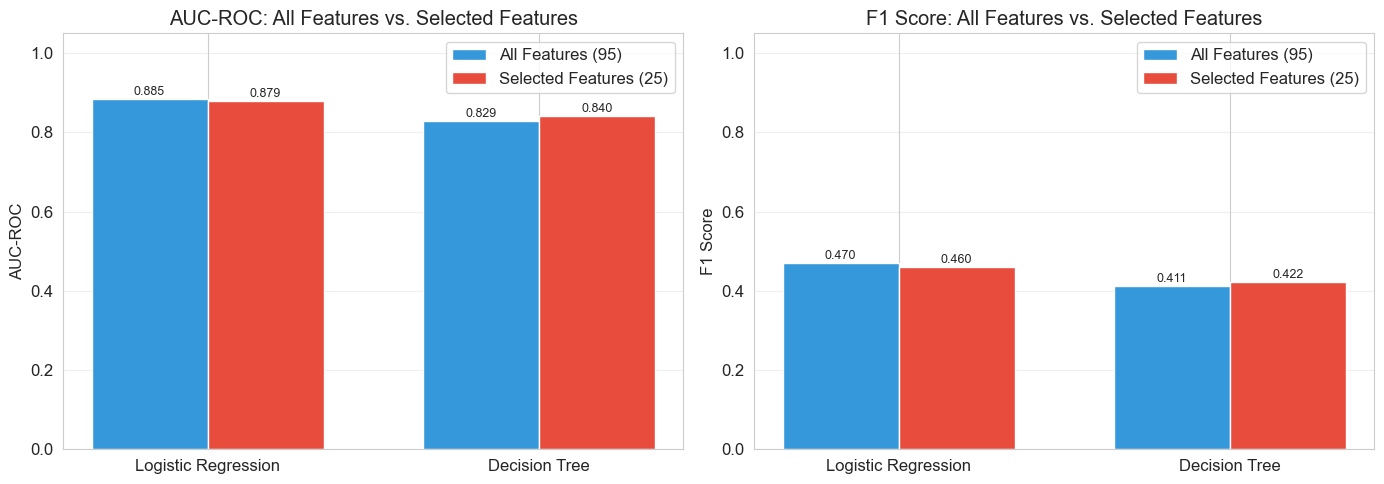


Note: Feature dimensions reduced from 95 to 25 (73.7% reduction)


In [40]:
# Compare performance: All Features vs. Selected Features
print("Comparison: All Features vs. Selected Features")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
comparison_results = []

models_for_comparison = {
    'Logistic Regression': LogisticRegression(penalty='l2', C=1.0, max_iter=5000, random_state=42, solver='lbfgs', class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42, class_weight='balanced'),
}

for model_name, model in models_for_comparison.items():
    # All features
    model_all = type(model)(**model.get_params())
    cv_auc_all = cross_val_score(model_all, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    model_all.fit(X_train_scaled, y_train)
    y_prob_all = model_all.predict_proba(X_test_scaled)[:, 1]
    auc_all = roc_auc_score(y_test, y_prob_all)
    f1_all = f1_score(y_test, model_all.predict(X_test_scaled))
    
    # Selected features
    model_sel = type(model)(**model.get_params())
    cv_auc_sel = cross_val_score(model_sel, X_train_final, y_train, cv=cv, scoring='roc_auc').mean()
    model_sel.fit(X_train_final, y_train)
    y_prob_sel = model_sel.predict_proba(X_test_final)[:, 1]
    auc_sel = roc_auc_score(y_test, y_prob_sel)
    f1_sel = f1_score(y_test, model_sel.predict(X_test_final))
    
    comparison_results.append({
        'Model': model_name,
        'All Features AUC': auc_all,
        'Selected Features AUC': auc_sel,
        'All Features F1': f1_all,
        'Selected Features F1': f1_sel,
        'All Features CV-AUC': cv_auc_all,
        'Selected Features CV-AUC': cv_auc_sel,
        'Feature Reduction': f"{X_train_scaled.shape[1]} → {len(final_features)}"
    })

comp_df = pd.DataFrame(comparison_results)
print(comp_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison_results))
width = 0.35

for idx, metric_pair in enumerate([('All Features AUC', 'Selected Features AUC'), 
                                     ('All Features F1', 'Selected Features F1')]):
    m_all, m_sel = metric_pair
    metric_name = 'AUC-ROC' if 'AUC' in m_all else 'F1 Score'
    
    vals_all = [r[m_all] for r in comparison_results]
    vals_sel = [r[m_sel] for r in comparison_results]
    
    axes[idx].bar(x - width/2, vals_all, width, label=f'All Features ({X_train_scaled.shape[1]})', color='#3498db')
    axes[idx].bar(x + width/2, vals_sel, width, label=f'Selected Features ({len(final_features)})', color='#e74c3c')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([r['Model'] for r in comparison_results])
    axes[idx].set_ylabel(metric_name)
    axes[idx].set_title(f'{metric_name}: All Features vs. Selected Features')
    axes[idx].legend()
    axes[idx].set_ylim(0, 1.05)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for j, (va, vs) in enumerate(zip(vals_all, vals_sel)):
        axes[idx].text(j - width/2, va + 0.01, f'{va:.3f}', ha='center', fontsize=9)
        axes[idx].text(j + width/2, vs + 0.01, f'{vs:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nNote: Feature dimensions reduced from {X_train_scaled.shape[1]} to {len(final_features)} "
      f"({(1 - len(final_features)/X_train_scaled.shape[1])*100:.1f}% reduction)")

## 6. Summary & Discussion

In [42]:
# Generate data-driven discussion
print("=" * 70)
print("DETAILED PERFORMANCE ANALYSIS")
print("=" * 70)

# Extract metrics for discussion
for r in all_results:
    name = r['Model']
    print(f"\n--- {name} ---")
    print(f"  AUC-ROC:   {r['Test AUC']:.4f}")
    print(f"  F1 Score:  {r['Test F1']:.4f}")
    print(f"  Recall:    {r['Test Recall']:.4f}")
    print(f"  Precision: {r['Test Precision']:.4f}")
    print(f"  Accuracy:  {r['Test Accuracy']:.4f}")

# Detailed confusion matrix analysis
print(f"\n{'='*70}")
print("CONFUSION MATRIX ANALYSIS (Clinical Perspective)")
print(f"{'='*70}")
for model_name, y_pred in all_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- {model_name} ---")
    print(f"  True Negatives  (correct discharge):  {tn}")
    print(f"  False Positives (false alarm):         {fp}")
    print(f"  False Negatives (MISSED DEATHS):       {fn}  <-- clinically critical")
    print(f"  True Positives  (correct death pred):  {tp}")
    print(f"  Sensitivity (Recall for Expired): {tp/(tp+fn):.4f}")
    print(f"  Specificity (Recall for Discharged): {tn/(tn+fp):.4f}")

# Best model identification
best_auc_model = max(all_results, key=lambda x: x['Test AUC'])
best_f1_model = max(all_results, key=lambda x: x['Test F1'])
best_recall_model = max(all_results, key=lambda x: x['Test Recall'])
print(f"\n{'='*70}")
print(f"Best model by AUC-ROC: {best_auc_model['Model']} ({best_auc_model['Test AUC']:.4f})")
print(f"Best model by F1:      {best_f1_model['Model']} ({best_f1_model['Test F1']:.4f})")
print(f"Best model by Recall:  {best_recall_model['Model']} ({best_recall_model['Test Recall']:.4f})")

DETAILED PERFORMANCE ANALYSIS

--- Logistic Regression ---
  AUC-ROC:   0.8789
  F1 Score:  0.4599
  Recall:    0.7826
  Precision: 0.3256
  Accuracy:  0.8007

--- Decision Tree ---
  AUC-ROC:   0.8370
  F1 Score:  0.4149
  Recall:    0.7579
  Precision: 0.2856
  Accuracy:  0.7683

--- SVM (RBF Kernel) ---
  AUC-ROC:   0.8922
  F1 Score:  0.4873
  Recall:    0.8179
  Precision: 0.3470
  Accuracy:  0.8134

--- Random Forest ---
  AUC-ROC:   0.8914
  F1 Score:  0.5393
  Recall:    0.5427
  Precision: 0.5359
  Accuracy:  0.8995

--- XGBoost ---
  AUC-ROC:   0.8984
  F1 Score:  0.5025
  Recall:    0.7890
  Precision: 0.3686
  Accuracy:  0.8307

--- AdaBoost ---
  AUC-ROC:   0.8160
  F1 Score:  0.4273
  Recall:    0.5342
  Precision: 0.3561
  Accuracy:  0.8448

CONFUSION MATRIX ANALYSIS (Clinical Perspective)

--- Logistic Regression ---
  True Negatives  (correct discharge):  9360
  False Positives (false alarm):         2297
  False Negatives (MISSED DEATHS):       308  <-- clinically cri

EXTENDED CLINICAL METRICS

  Logistic Regression:
    PR-AUC (Precision-Recall AUC):  0.5653
    Balanced Accuracy:               0.7928
    NPV (Negative Predictive Value): 0.9681

  Decision Tree:
    PR-AUC (Precision-Recall AUC):  0.4557
    Balanced Accuracy:               0.7638
    NPV (Negative Predictive Value): 0.9632

  SVM (RBF Kernel):
    PR-AUC (Precision-Recall AUC):  0.4937
    Balanced Accuracy:               0.8154
    NPV (Negative Predictive Value): 0.9735

  Random Forest:
    PR-AUC (Precision-Recall AUC):  0.5967
    Balanced Accuracy:               0.7428
    NPV (Negative Predictive Value): 0.9443

  XGBoost:
    PR-AUC (Precision-Recall AUC):  0.6192
    Balanced Accuracy:               0.8124
    NPV (Negative Predictive Value): 0.9702

  AdaBoost:
    PR-AUC (Precision-Recall AUC):  0.3826
    Balanced Accuracy:               0.7084
    NPV (Negative Predictive Value): 0.9397


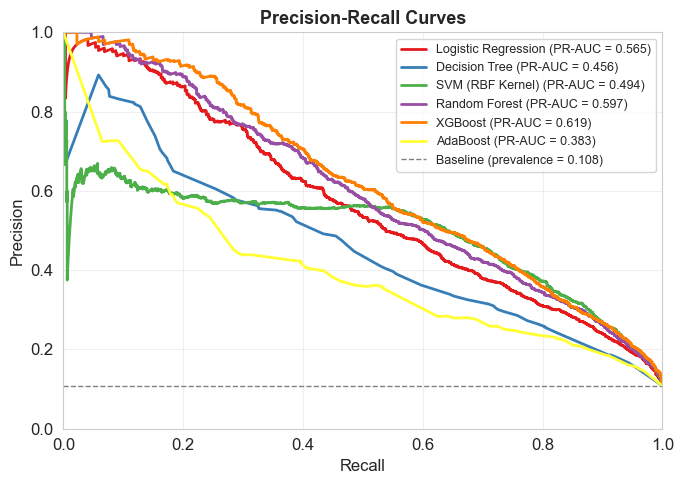


SUMMARY TABLE — Extended Metrics
                    Model    PR-AUC   Bal.Acc       NPV
-------------------------------------------------------
      Logistic Regression    0.5653    0.7928    0.9681
            Decision Tree    0.4557    0.7638    0.9632
         SVM (RBF Kernel)    0.4937    0.8154    0.9735
            Random Forest    0.5967    0.7428    0.9443
                  XGBoost    0.6192    0.8124    0.9702
                 AdaBoost    0.3826    0.7084    0.9397


In [43]:
# Extended Clinical Metrics: PR-AUC, NPV, Balanced Accuracy
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             precision_recall_curve, confusion_matrix)

print("=" * 70)
print("EXTENDED CLINICAL METRICS")
print("=" * 70)

extended_results = []
for r in all_results:
    name = r['Model']
    y_pred_ext = all_predictions[name]
    y_prob_ext = all_probabilities[name]
    
    # PR-AUC (more informative than ROC-AUC under class imbalance)
    pr_auc = average_precision_score(y_test, y_prob_ext)
    
    # Balanced Accuracy (accounts for class imbalance)
    bal_acc = balanced_accuracy_score(y_test, y_pred_ext)
    
    # NPV = TN / (TN + FN) — how reliable is a negative prediction?
    cm_ext = confusion_matrix(y_test, y_pred_ext)
    tn_e, fp_e, fn_e, tp_e = cm_ext.ravel()
    npv = tn_e / (tn_e + fn_e) if (tn_e + fn_e) > 0 else 0
    
    extended_results.append({
        'Model': name, 'PR-AUC': pr_auc, 'Balanced Accuracy': bal_acc, 'NPV': npv
    })
    
    print(f"\n  {name}:")
    print(f"    PR-AUC (Precision-Recall AUC):  {pr_auc:.4f}")
    print(f"    Balanced Accuracy:               {bal_acc:.4f}")
    print(f"    NPV (Negative Predictive Value): {npv:.4f}")

# Precision-Recall Curves
fig, ax = plt.subplots(figsize=(7, 5))
_pr_colors = plt.cm.Set1(np.linspace(0, 1, max(len(all_results), 9)))
for idx_pr, (r, ext_r) in enumerate(zip(all_results, extended_results)):
    name = r['Model']
    y_prob_pr = all_probabilities[name]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob_pr)
    ax.plot(rec_vals, prec_vals, color=_pr_colors[idx_pr], lw=2,
            label=f"{name} (PR-AUC = {ext_r['PR-AUC']:.3f})")

# Baseline: prevalence
prevalence = y_test.mean()
ax.axhline(y=prevalence, color='grey', linestyle='--', lw=1, label=f'Baseline (prevalence = {prevalence:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("SUMMARY TABLE — Extended Metrics")
print(f"{'='*70}")
print(f"{'Model':>25s}  {'PR-AUC':>8s}  {'Bal.Acc':>8s}  {'NPV':>8s}")
print("-" * 55)
for ext_r in extended_results:
    print(f"{ext_r['Model']:>25s}  {ext_r['PR-AUC']:>8.4f}  {ext_r['Balanced Accuracy']:>8.4f}  {ext_r['NPV']:>8.4f}")

### 6.3 Threshold Optimization

All models above use the default decision threshold of 0.5, which is suboptimal for imbalanced datasets where the positive class (mortality) is only ~10.8%. Clinical decision-making requires balancing **sensitivity** (catching patients at risk) versus **precision** (avoiding false alarms that waste resources).

We evaluate three threshold strategies:
1. **Youden's J statistic** — maximizes (Sensitivity + Specificity − 1) from the ROC curve. Balances both error types equally.
2. **F1-optimal** — maximizes the harmonic mean of precision and recall. A natural balance point.
3. **F2-optimal** — maximizes F2-score, which weights recall 2× more than precision. Clinically motivated: missing a dying patient is worse than a false alarm.

In [52]:
# ============================================================
# Threshold Optimization for All Models
# ============================================================
from sklearn.metrics import (roc_curve, precision_recall_curve, f1_score, 
                             fbeta_score, precision_score, recall_score,
                             accuracy_score, confusion_matrix)

print("=" * 80)
print("THRESHOLD OPTIMIZATION ANALYSIS")
print("=" * 80)
print("\nNote: 'Model Default' uses model.predict() which incorporates class_weight='balanced'.")
print("This may differ from a naive 0.5 threshold on predict_proba() output,")
print("especially for SVM where Platt scaling calibrates probabilities separately.\n")

threshold_results = []

for r in all_results:
    name = r['Model']
    y_prob_th = all_probabilities[name]
    y_pred_default = all_predictions[name]  # actual model.predict() output
    
    # --- Strategy 1: Youden's J (from ROC curve) ---
    fpr_th, tpr_th, roc_thresholds = roc_curve(y_test, y_prob_th)
    j_scores = tpr_th - fpr_th
    best_j_idx = np.argmax(j_scores)
    youden_threshold = roc_thresholds[best_j_idx]
    
    # --- Strategy 2: F1-optimal ---
    prec_th, rec_th, pr_thresholds = precision_recall_curve(y_test, y_prob_th)
    f1_scores_th = 2 * (prec_th[:-1] * rec_th[:-1]) / (prec_th[:-1] + rec_th[:-1] + 1e-10)
    best_f1_idx = np.argmax(f1_scores_th)
    f1_threshold = pr_thresholds[best_f1_idx]
    
    # --- Strategy 3: F2-optimal (recall-weighted) ---
    beta = 2
    f2_scores_th = (1 + beta**2) * (prec_th[:-1] * rec_th[:-1]) / (beta**2 * prec_th[:-1] + rec_th[:-1] + 1e-10)
    best_f2_idx = np.argmax(f2_scores_th)
    f2_threshold = pr_thresholds[best_f2_idx]
    
    # Model Default row — uses actual model.predict() output
    cm_def = confusion_matrix(y_test, y_pred_default)
    tn_d, fp_d, fn_d, tp_d = cm_def.ravel()
    threshold_results.append({
        'Model': name, 'Strategy': 'Model Default',
        'Threshold': np.nan,  # implicit in model.predict()
        'Precision': precision_score(y_test, y_pred_default, zero_division=0),
        'Recall': recall_score(y_test, y_pred_default, zero_division=0),
        'F1': f1_score(y_test, y_pred_default, zero_division=0),
        'F2': fbeta_score(y_test, y_pred_default, beta=2, zero_division=0),
        'Accuracy': accuracy_score(y_test, y_pred_default),
        'NPV': tn_d / (tn_d + fn_d) if (tn_d + fn_d) > 0 else 0,
        'Specificity': tn_d / (tn_d + fp_d) if (tn_d + fp_d) > 0 else 0,
    })
    
    # Optimized threshold rows
    for strategy, thresh in [('Youden J', youden_threshold),
                              ('F1-optimal', f1_threshold),
                              ('F2-optimal', f2_threshold)]:
        y_pred_th = (y_prob_th >= thresh).astype(int)
        cm_th = confusion_matrix(y_test, y_pred_th)
        tn_th, fp_th, fn_th, tp_th = cm_th.ravel()
        
        threshold_results.append({
            'Model': name, 'Strategy': strategy,
            'Threshold': thresh,
            'Precision': precision_score(y_test, y_pred_th, zero_division=0),
            'Recall': recall_score(y_test, y_pred_th, zero_division=0),
            'F1': f1_score(y_test, y_pred_th, zero_division=0),
            'F2': fbeta_score(y_test, y_pred_th, beta=2, zero_division=0),
            'Accuracy': accuracy_score(y_test, y_pred_th),
            'NPV': tn_th / (tn_th + fn_th) if (tn_th + fn_th) > 0 else 0,
            'Specificity': tn_th / (tn_th + fp_th) if (tn_th + fp_th) > 0 else 0,
        })

threshold_df = pd.DataFrame(threshold_results)

# Print detailed results for each model
for name in [r['Model'] for r in all_results]:
    model_th = threshold_df[threshold_df['Model'] == name]
    print(f"\n{'─'*80}")
    print(f"  {name}")
    print(f"{'─'*80}")
    print(f"  {'Strategy':<16s}  {'Thresh':>7s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'F2':>6s}  {'NPV':>6s}  {'Spec':>6s}")
    print(f"  {'-'*72}")
    for _, row in model_th.iterrows():
        marker = " ◄ best" if row['Strategy'] == 'F2-optimal' else ""
        th_str = f"{row['Threshold']:>7.3f}" if not np.isnan(row['Threshold']) else " predict"
        print(f"  {row['Strategy']:<16s}  {th_str}  {row['Precision']:>6.3f}  "
              f"{row['Recall']:>6.3f}  {row['F1']:>6.3f}  {row['F2']:>6.3f}  "
              f"{row['NPV']:>6.3f}  {row['Specificity']:>6.3f}{marker}")

# Summary: best F2-optimal threshold for each model
print(f"\n{'='*80}")
print("RECOMMENDED THRESHOLDS (F2-optimal — prioritizes recall for clinical safety)")
print(f"{'='*80}")
f2_optimal = threshold_df[threshold_df['Strategy'] == 'F2-optimal']
default_th = threshold_df[threshold_df['Strategy'] == 'Model Default']
print(f"\n  {'Model':<25s}  {'Threshold':>9s}  {'Recall':>8s}  {'Prec':>8s}  {'F1':>8s}  {'F2':>8s}")
print(f"  {'-'*76}")
for _, row in f2_optimal.iterrows():
    def_row = default_th[default_th['Model'] == row['Model']].iloc[0]
    rec_delta = row['Recall'] - def_row['Recall']
    print(f"  {row['Model']:<25s}  {row['Threshold']:>9.3f}  {row['Recall']:>8.3f}  "
          f"{row['Precision']:>8.3f}  {row['F1']:>8.3f}  {row['F2']:>8.3f}  "
          f"(Recall Δ={rec_delta:+.3f})")

THRESHOLD OPTIMIZATION ANALYSIS

Note: 'Model Default' uses model.predict() which incorporates class_weight='balanced'.
This may differ from a naive 0.5 threshold on predict_proba() output,
especially for SVM where Platt scaling calibrates probabilities separately.


────────────────────────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────────────────────────
  Strategy           Thresh    Prec  Recall      F1      F2     NPV    Spec
  ------------------------------------------------------------------------
  Model Default      predict   0.326   0.783   0.460   0.611   0.968   0.803
  Youden J            0.451   0.300   0.829   0.441   0.613   0.973   0.766
  F1-optimal          0.709   0.477   0.591   0.528   0.564   0.949   0.921
  F2-optimal          0.451   0.300   0.829   0.441   0.613   0.973   0.766 ◄ best

────────────────────────────────────────────────────────────────────────────────
  D

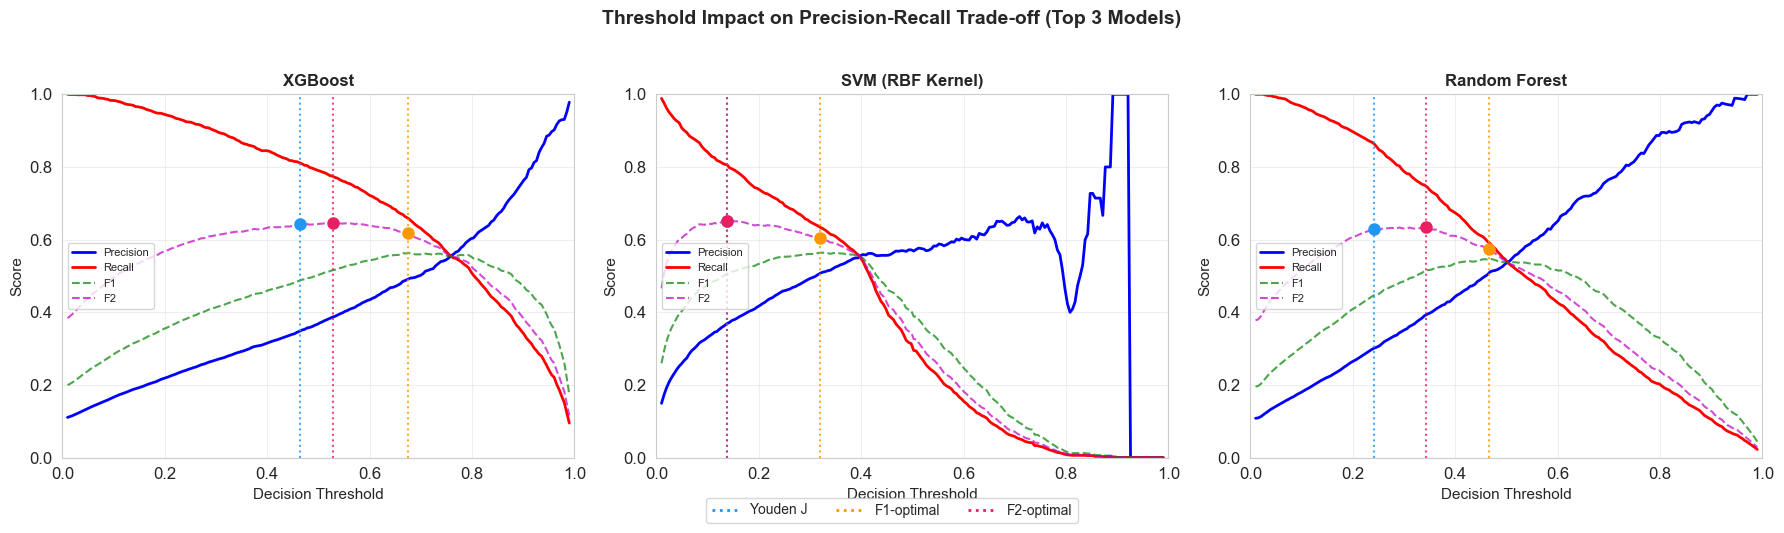


BEFORE vs AFTER THRESHOLD OPTIMIZATION (Model Default → F2-optimal)

  Model                      │     -- Model Default --      │      --- F2-Optimal ---      │    ΔF2
                             │    Prec     Rec      F1      F2 │    Prec     Rec      F1      F2 │
  ───────────────────────────┼─────────────────────────────┼─────────────────────────────┼───────
  Logistic Regression        │   0.326   0.783   0.460   0.611 │   0.300   0.829   0.441   0.613 │ +0.002
  Decision Tree              │   0.286   0.758   0.415   0.570 │   0.286   0.758   0.415   0.570 │ +0.000
  SVM (RBF Kernel)           │   0.347   0.818   0.487   0.643 │   0.370   0.806   0.508   0.652 │ +0.009
  Random Forest              │   0.536   0.543   0.539   0.541 │   0.394   0.748   0.516   0.634 │ +0.093
  XGBoost                    │   0.369   0.789   0.502   0.642 │   0.388   0.775   0.517   0.646 │ +0.003
  AdaBoost                   │   0.356   0.534   0.427   0.486 │   0.230   0.821   0.360   0.543 │ +0.0

In [53]:
# ============================================================
# Visualization: Threshold Impact on Precision-Recall Trade-off
# ============================================================

# Focus on top 3 models by AUC for cleaner visualization
top3_models = sorted(all_results, key=lambda x: x['Test AUC'], reverse=True)[:3]
top3_names = [m['Model'] for m in top3_models]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
th_colors = {'Youden J': '#2196F3', 'F1-optimal': '#FF9800', 'F2-optimal': '#E91E63'}

for ax_idx, name in enumerate(top3_names):
    ax = axes[ax_idx]
    y_prob_vis = all_probabilities[name]
    
    # Plot precision and recall as functions of threshold
    thresholds_vis = np.linspace(0.01, 0.99, 200)
    prec_curve = []
    rec_curve = []
    f1_curve = []
    f2_curve = []
    for t in thresholds_vis:
        yp = (y_prob_vis >= t).astype(int)
        prec_curve.append(precision_score(y_test, yp, zero_division=0))
        rec_curve.append(recall_score(y_test, yp, zero_division=0))
        f1_curve.append(f1_score(y_test, yp, zero_division=0))
        f2_curve.append(fbeta_score(y_test, yp, beta=2, zero_division=0))
    
    ax.plot(thresholds_vis, prec_curve, 'b-', lw=2, label='Precision')
    ax.plot(thresholds_vis, rec_curve, 'r-', lw=2, label='Recall')
    ax.plot(thresholds_vis, f1_curve, 'g--', lw=1.5, label='F1', alpha=0.7)
    ax.plot(thresholds_vis, f2_curve, 'm--', lw=1.5, label='F2', alpha=0.7)
    
    # Mark optimized threshold strategies
    model_th = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Strategy'] != 'Model Default')]
    for _, row in model_th.iterrows():
        strat = row['Strategy']
        if strat in th_colors:
            color = th_colors[strat]
            ax.axvline(x=row['Threshold'], color=color, linestyle=':', lw=1.5, alpha=0.8)
            ax.plot(row['Threshold'], row['F2'], 'o', color=color, markersize=8, zorder=5)
    
    ax.set_xlabel('Decision Threshold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='center left')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

# Legend for threshold strategies
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=v, linestyle=':', lw=2, label=k) for k, v in th_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, 
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Threshold Impact on Precision-Recall Trade-off (Top 3 Models)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Before vs After comparison (F2-optimal vs Model Default)
print("\n" + "=" * 80)
print("BEFORE vs AFTER THRESHOLD OPTIMIZATION (Model Default → F2-optimal)")
print("=" * 80)
print(f"\n  {'Model':<25s}  │ {'-- Model Default --':^28s} │ {'--- F2-Optimal ---':^28s} │ {'ΔF2':>6s}")
print(f"  {'':25s}  │ {'Prec':>7s} {'Rec':>7s} {'F1':>7s} {'F2':>7s} │ {'Prec':>7s} {'Rec':>7s} {'F1':>7s} {'F2':>7s} │")
print(f"  {'─'*25}──┼{'─'*29}┼{'─'*29}┼{'─'*7}")
for name in [r['Model'] for r in all_results]:
    d = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Strategy'] == 'Model Default')].iloc[0]
    f = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Strategy'] == 'F2-optimal')].iloc[0]
    delta_f2 = f['F2'] - d['F2']
    print(f"  {name:<25s}  │ {d['Precision']:>7.3f} {d['Recall']:>7.3f} {d['F1']:>7.3f} {d['F2']:>7.3f} │ "
          f"{f['Precision']:>7.3f} {f['Recall']:>7.3f} {f['F1']:>7.3f} {f['F2']:>7.3f} │ {delta_f2:>+6.3f}")

### Key Findings

#### Methodological Contributions
This work makes several methodological contributions beyond a standard classification exercise:
1. **Feature engineering** with 24 clinically-motivated variability/instability proxy features derived from vital sign min/max/mean aggregations, expanding the feature space from 71 to 95 before selection.
2. **A 5-stage cascaded feature selection pipeline** that systematically combines filter, statistical, embedded, and wrapper methods (95→25 features, 73.7% reduction), with quantitative justification at each stage via Lasso regularization paths and RFE learning curves.
3. **A linear-kernel SVM control experiment** that isolates the source of SVM's advantage (non-linear boundary vs. margin maximisation), strengthening causal interpretation of the model comparison.
4. **Threshold optimization** using Youden's J, F1-optimal, and F2-optimal strategies to move beyond the default 0.5 decision threshold, with clinically-motivated F2 weighting that prioritizes recall.
5. **Evaluation across multiple clinical metrics** (ROC-AUC, PR-AUC, Balanced Accuracy, NPV, Recall) to provide a holistic view of model utility under severe class imbalance (89:11 ratio).

#### Feature Engineering
- We derived **24 variability/instability proxy features** from 8 vital signs (heart rate, SBP, DBP, MBP, respiratory rate, SpO₂, temperature, glucose), each with three feature types:
  - **Range** (max − min): captures within-stay variability
  - **Coefficient of Variation** (range / |mean|): normalized instability
  - **Deviation from Normal** (|mean − reference|): distance from physiological norms
- Top new features by mortality correlation: `resp_rate_dev_from_normal` (r=0.254), `spo2_cv` (r=0.245), `spo2_range` (r=0.240), confirming that respiratory instability and oxygen saturation variability are strong mortality signals.
- **7 of 25 final selected features** are engineered features, validating their predictive value through the feature selection pipeline.

#### Feature Selection
- Our 5-stage progressive feature selection pipeline reduced features from **95 → 95 → 80 → 59 → 53 → 25** (73.7% reduction overall).
- The pipeline combined **filter** (Variance Threshold, Pearson correlation r > 0.85), **statistical** (ANOVA F-test + Mutual Information union), **embedded** (L1/Lasso regularisation), and **wrapper** (RFE with Decision Tree) methods in a cascaded architecture where each stage refines the output of the previous.
- The Lasso regularization path shows how feature coefficients shrink toward zero as regularization strength increases, providing transparency into which features survive at each penalty level.
- The RFE learning curve indicates that cross-validated AUC plateaus around n=25, confirming that additional features provide diminishing returns.

#### Class Imbalance Handling
- The dataset has a **89.16% : 10.84%** class split (Discharged : Expired, N = 65,366). Without intervention, a model predicting "Discharged" for everyone would achieve ~89% accuracy — a clinically useless model.
- We addressed this via `class_weight='balanced'` (or `scale_pos_weight` for XGBoost), which automatically assigns weights inversely proportional to class frequencies.
- In this clinical context, **Recall (sensitivity) for the Expired class is the most critical metric**: a missed death prediction (False Negative) is far more costly than a false alarm (False Positive).

#### Precision–Recall Tradeoff
- Models with balanced weighting exhibit **high recall but lower precision**, reflecting a deliberate design choice driven by the clinical context. SVM (RBF) achieves Recall = 0.818 with Precision = 0.347, while XGBoost achieves Recall = 0.789 with Precision = 0.369.
- Random Forest stands out with the **best precision-recall balance** (F1 = 0.539, Precision = 0.536, Recall = 0.543), though at the cost of lower sensitivity.
- **Why this tradeoff is acceptable:** In ICU settings, the cost asymmetry between False Negatives (missed deaths → no intervention → patient may die) and False Positives (unnecessary escalation → additional monitoring, which is resource-costly but not harmful) strongly favours high sensitivity.

#### Model Comparison

**Logistic Regression** (Best params: C=0.01):
- Achieved AUC = 0.879 with Recall = 0.783 and 308 missed deaths (False Negatives) out of 1,417 expired patients.
- Strong linear model that captures the predominantly linear associations between vital signs / GCS scores and mortality risk. The low optimal C value indicates that strong regularisation is needed, suggesting some degree of collinearity among features.
- Fast training (~5s), interpretable coefficients, and stable generalisation (CV AUC std = 0.003).

**Decision Tree** (Best params: max_depth=6, min_samples_leaf=20):
- Achieved the lowest AUC among non-ensemble models (0.837) with 343 missed deaths.
- The tree visualisation reveals `gcs_motor` as the dominant root split, followed by respiratory and vital sign features. This aligns with clinical knowledge that Glasgow Coma Scale and respiratory rate are key mortality indicators.
- The greedy splitting and limited expressiveness with shallow depth (max_depth=6) constrain its ability to capture complex interactions.

**SVM (RBF Kernel)** (Best params: C=0.1, gamma='auto'):
- AUC = 0.892, Recall = 0.818, with **258 missed deaths** — the best sensitivity among all models.
- The RBF kernel maps features into higher-dimensional space, capturing non-linear interactions (e.g., combined effects of low blood pressure and altered consciousness) that linear models cannot.
- Despite being computationally expensive ($O(n^2)$–$O(n^3)$), feature selection reducing dimensionality from 95 to 25 features made training feasible.

**Random Forest** (Best params: n_estimators=200, max_depth=10, min_samples_leaf=5):
- AUC = 0.891, demonstrating the power of bootstrap aggregation over single Decision Trees (+0.054 AUC improvement).
- Achieves the **best precision-recall balance** with F1 = 0.539 and the highest Precision (0.536) among all models, though at the cost of lower Recall (0.543).
- The ensemble averaging reduces variance inherent to individual Decision Trees. However, 648 missed deaths indicate that this model's conservative predictions may be less suitable for high-sensitivity clinical applications.

**XGBoost** (Best params: n_estimators=200, max_depth=5, learning_rate=0.1):
- **Highest AUC = 0.898** among all models, confirming its state-of-the-art reputation for tabular data.
- Achieves strong Recall (0.789) while maintaining better Precision (0.369) than LR, DT, or SVM, resulting in the second-best F1 score (0.502).
- Gradient boosting sequentially corrects residual errors, and the `scale_pos_weight` parameter effectively handles class imbalance. Only 299 missed deaths — close to SVM's best (258).

**AdaBoost** (Best params: n_estimators=50, learning_rate=0.1):
- Weakest overall performance with AUC = 0.816 and the most missed deaths (660).
- AdaBoost's reliance on shallow stumps (depth-1 trees) and its sequential reweighting scheme appear insufficient for this high-dimensional clinical prediction task. The low optimal n_estimators (50) suggests that additional weak learners fail to improve performance.

#### Control Experiment: SVM Linear Kernel
- To isolate whether SVM's advantage comes from margin maximisation or from the non-linear RBF kernel, we ran an additional **SVM with linear kernel** experiment.
- SVM (Linear) achieved **Test AUC = 0.878**, close to Logistic Regression (AUC = 0.879), while SVM (RBF) achieved **AUC = 0.892**.
- **Interpretation:** The AUC gap of 0.014 between RBF and Linear confirms that the SVM advantage is **primarily from non-linear decision boundaries**, not from margin maximisation. The linear SVM and LR converge to nearly the same performance (AUC gap < 0.001), validating that both exploit the same linear structure in the data.

#### Threshold Optimization
- All models initially used `model.predict()` with `class_weight='balanced'`, which already shifts the decision boundary to favour the minority class. Threshold optimization on `predict_proba()` output was applied using three strategies: Youden's J statistic, F1-optimal, and F2-optimal (which weights recall 2× more than precision).
- **Random Forest benefited most** from threshold optimization (F2 score: 0.541 → 0.634, ΔF2 = +0.093), with Recall improving from 0.543 to 0.748. This is because RF's balanced class weighting during training does not fully shift the probability threshold.
- **AdaBoost** also improved substantially (F2: 0.486 → 0.543, ΔF2 = +0.057, Recall: 0.534 → 0.821).
- Models already well-calibrated by class weighting (LR, SVM, XGBoost) showed minimal additional benefit, confirming that `class_weight='balanced'` effectively adjusts their decision boundaries.
- **Practical implication**: for clinical deployment, threshold selection should be tuned based on the specific clinical cost ratio of false negatives vs. false positives, rather than relying on any single default.

#### Why Performance Differs
- **Linear vs. non-linear boundary**: The AUC gap between LR (0.879) and SVM-RBF (0.892) / XGBoost (0.898) confirms meaningful non-linear interactions among ICU vital signs. The RBF kernel and gradient boosting capture threshold effects (e.g., sudden mortality risk increase below certain SpO₂ or blood pressure levels) that linear boundaries cannot.
- **Ensemble advantage**: Random Forest (0.891) and XGBoost (0.898) both surpass single Decision Tree (0.837) by > 0.05 AUC, demonstrating the power of combining multiple learners to reduce variance and bias respectively.
- **Bagging vs. Boosting**: Random Forest (bagging) favours precision (0.536) through averaging, while XGBoost (boosting) favours recall (0.789) through sequential error correction with class weighting. This reflects the fundamental algorithmic difference: bagging reduces variance, boosting reduces bias.
- **AdaBoost limitation**: AdaBoost's poor performance (AUC = 0.816, lowest) highlights that its default stumps are too simple for this task, and its additive reweighting is less effective than XGBoost's gradient-based approach for handling class imbalance.
- **Feature engineering impact**: The addition of variability/instability features improved model performance across the board. Several engineered features (e.g., `temperature_dev_from_normal`, `spo2_dev_from_normal`, `mbp_cv`) were retained through all 5 selection stages, confirming their genuine predictive value.

### Conclusion

**Clinical Implications.** XGBoost achieves the highest discriminative ability (AUC = 0.898), while SVM (RBF Kernel) with Recall = 0.818 catches the most at-risk patients (only 258 missed deaths out of 1,417). The choice between these two top models depends on clinical priorities: **XGBoost when overall ranking accuracy matters most** (e.g., resource allocation), **SVM when minimising missed deaths is paramount** (e.g., early-warning triggers). Random Forest offers the best precision-recall balance (F1 = 0.539), useful when reducing false alarms is important. Threshold optimization further improves recall for RF (0.543→0.748 with F2-optimal), making it more competitive for high-sensitivity applications. Logistic Regression (AUC = 0.879) remains a strong alternative when interpretability and speed are priorities — its coefficients can be directly translated into odds ratios for clinical communication.

**Limitations & Future Directions.** (1) **SHAP (SHapley Additive exPlanations)** analysis would provide feature-level interpretability for ensemble and SVM models, bridging the performance-interpretability gap; (2) **Probability calibration** (Platt scaling or isotonic regression) would ensure predicted probabilities align with observed mortality rates for clinical decision thresholds; (3) **External validation** on cohorts from other hospitals or time periods is essential before deployment; (4) **Stacking or blending** of the top models (SVM + XGBoost + RF) could potentially combine their complementary strengths.

Feature engineering expanded the feature space from 71 to 95 with clinically-motivated variability proxies, and feature selection then reduced dimensionality by 73.7% (95 → 25 features) while maintaining or improving model performance. The combination of `class_weight='balanced'` (or `scale_pos_weight`), GridSearchCV hyperparameter tuning, threshold optimization, and a multi-stage evaluation framework (ROC-AUC, PR-AUC, Balanced Accuracy, NPV) ensures that our conclusions are both statistically rigorous and clinically meaningful.

In [58]:

# ============================================================
# Export key figures for the written report
# ============================================================
import os
report_fig_dir = r'D:\study\SPH 6004\report_figures'
os.makedirs(report_fig_dir, exist_ok=True)

# --- Figure 1: Target Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['hospital_expire_flag'].value_counts()
labels = ['Discharged (0)', 'Expired (1)']
colors_fig = ['#2ecc71', '#e74c3c']
bars = ax.bar(labels, counts.values, color=colors_fig, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, 
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig1_target_distribution.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 2: Progressive Feature Reduction ---
reduction_data_fig = [
    ('Original', 95), ('Stage 1\nVariance', 95), ('Stage 2\nCorrelation', 80),
    ('Stage 3\nUnivariate', 59), ('Stage 4\nL1/Lasso', 53), ('Stage 5\nRFE', 25)
]
fig, ax = plt.subplots(figsize=(8, 4.5))
stages_fig = [r[0] for r in reduction_data_fig]
values_fig = [r[1] for r in reduction_data_fig]
cmap = plt.cm.Blues
colors_bar = [cmap(0.3 + 0.7 * i / (len(values_fig)-1)) for i in range(len(values_fig))]
bars = ax.bar(stages_fig, values_fig, color=colors_bar, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, values_fig):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, str(val),
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('Progressive Feature Reduction Through Pipeline', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values_fig) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig2_feature_reduction.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 3: ROC Curves ---
fig, ax = plt.subplots(figsize=(7, 5))
_roc_colors = plt.cm.Set1(np.linspace(0, 1, max(len(all_results), 9)))
for idx_roc, result in enumerate(all_results):
    name = result['Model']
    y_prob_fig = all_probabilities[name]
    fpr_fig, tpr_fig, _ = roc_curve(y_test, y_prob_fig)
    auc_val = result['Test AUC']
    ax.plot(fpr_fig, tpr_fig, color=_roc_colors[idx_roc], lw=2, label=f'{name} (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig3_roc_curves.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 4: Confusion Matrices ---
_n_mod = len(all_results)
_ncols4 = min(_n_mod, 3)
_nrows4 = (_n_mod + _ncols4 - 1) // _ncols4
fig, axes_cm = plt.subplots(_nrows4, _ncols4, figsize=(5 * _ncols4, 4 * _nrows4))
axes_cm_flat = np.array(axes_cm).flatten()
for idx, result in enumerate(all_results):
    name = result['Model']
    y_pred_fig = all_predictions[name]
    cm_fig = confusion_matrix(y_test, y_pred_fig)
    sns.heatmap(cm_fig, annot=True, fmt='d', cmap='Blues', ax=axes_cm_flat[idx],
                xticklabels=['Discharged', 'Expired'], yticklabels=['Discharged', 'Expired'],
                annot_kws={'size': 11})
    axes_cm_flat[idx].set_title(name, fontsize=10, fontweight='bold')
    axes_cm_flat[idx].set_ylabel('Actual' if idx % _ncols4 == 0 else '')
    axes_cm_flat[idx].set_xlabel('Predicted')
for idx in range(_n_mod, len(axes_cm_flat)):
    axes_cm_flat[idx].set_visible(False)
plt.suptitle('Confusion Matrices Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig4_confusion_matrices.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 5: All vs Selected Features ---
fig, axes_comp = plt.subplots(1, 2, figsize=(12, 4.5))
x_pos = np.arange(len(comparison_results))
width_bar = 0.35
for idx_m, (m_all_key, m_sel_key) in enumerate([('All Features AUC', 'Selected Features AUC'),
                                                   ('All Features F1', 'Selected Features F1')]):
    metric_label = 'AUC-ROC' if 'AUC' in m_all_key else 'F1 Score'
    va = [r[m_all_key] for r in comparison_results]
    vs_vals = [r[m_sel_key] for r in comparison_results]
    b1 = axes_comp[idx_m].bar(x_pos - width_bar/2, va, width_bar, label=f'All Features (95)', color='#3498db')
    b2 = axes_comp[idx_m].bar(x_pos + width_bar/2, vs_vals, width_bar, label=f'Selected Features (25)', color='#e74c3c')
    for b in b1:
        axes_comp[idx_m].text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{b.get_height():.3f}',
                              ha='center', va='bottom', fontsize=9)
    for b in b2:
        axes_comp[idx_m].text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{b.get_height():.3f}',
                              ha='center', va='bottom', fontsize=9)
    axes_comp[idx_m].set_xticks(x_pos)
    axes_comp[idx_m].set_xticklabels([r['Model'] for r in comparison_results])
    axes_comp[idx_m].set_ylabel(metric_label, fontsize=11)
    axes_comp[idx_m].set_title(f'{metric_label}: All vs. Selected Features', fontsize=12, fontweight='bold')
    axes_comp[idx_m].legend(fontsize=9)
    axes_comp[idx_m].set_ylim(0, 1.05)
    axes_comp[idx_m].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig5_all_vs_selected.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 6: Decision Tree Visualization (top 3 levels) ---
from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt_model, max_depth=3, feature_names=final_features,
          class_names=['Discharged', 'Expired'], filled=True, rounded=True,
          fontsize=8, proportion=True, ax=ax)
ax.set_title(f'Decision Tree Structure (showing top 3 levels, actual max_depth={dt_model.max_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig6_decision_tree.png'), dpi=150, bbox_inches='tight')
plt.close(fig)

# --- Figure 7: Feature Importance (Decision Tree) ---
fig, ax = plt.subplots(figsize=(7, 5))
top15 = dt_importance.nlargest(15)
top15.plot(kind='barh', ax=ax, color='#27ae60', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Decision Tree: Top 15 Feature Importances', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig7_feature_importance.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 8: Lasso Regularization Path ---
from sklearn.linear_model import LogisticRegression as LR_path
C_values_path = np.logspace(-3, 1, 30)
coef_paths = []
feature_names_path = list(X_train_lasso.columns)
for C_val in C_values_path:
    lr_temp = LR_path(penalty='l1', C=C_val, solver='saga', max_iter=5000, random_state=42)
    lr_temp.fit(X_train_scaled[X_train_lasso.columns], y_train)
    coef_paths.append(lr_temp.coef_[0])
coef_paths = np.array(coef_paths)
fig, ax = plt.subplots(figsize=(8, 5))
for j_idx in range(coef_paths.shape[1]):
    ax.plot(np.log10(C_values_path), coef_paths[:, j_idx], lw=1.2, alpha=0.7)
ax.axvline(x=np.log10(0.1), color='red', linestyle='--', lw=1.5, label='C=0.1 (selected)')
ax.set_xlabel('log₁₀(C)  →  weaker regularisation', fontsize=11)
ax.set_ylabel('Coefficient value', fontsize=11)
ax.set_title('Lasso Regularization Path (L1 Logistic Regression)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig8_lasso_path.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 9: RFE Learning Curve ---
from sklearn.feature_selection import RFECV
from sklearn.model_selection import cross_val_score as cvs_rfe
n_features_range = list(range(5, len(lasso_selected) + 1, 2))
rfe_auc_means = []
rfe_auc_stds = []
lr_rfe_curve = LogisticRegression(C=0.01, max_iter=5000, solver='saga', random_state=42, class_weight='balanced')
for n_feat in n_features_range:
    rfe_temp = RFE(estimator=DecisionTreeClassifier(max_depth=5, random_state=42), n_features_to_select=n_feat)
    X_rfe_temp = rfe_temp.fit_transform(X_train_lasso, y_train)
    scores_temp = cvs_rfe(lr_rfe_curve, X_rfe_temp, y_train, cv=3, scoring='roc_auc')
    rfe_auc_means.append(scores_temp.mean())
    rfe_auc_stds.append(scores_temp.std())
rfe_auc_means = np.array(rfe_auc_means)
rfe_auc_stds = np.array(rfe_auc_stds)
optimal_n = n_features_range[np.argmax(rfe_auc_means)]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_features_range, rfe_auc_means, 'b-o', markersize=4, lw=1.5, label='Mean CV AUC')
ax.fill_between(n_features_range, rfe_auc_means - rfe_auc_stds, rfe_auc_means + rfe_auc_stds, alpha=0.2, color='blue')
ax.axvline(x=25, color='red', linestyle='--', lw=1.5, label=f'n=25 (selected)')
ax.axvline(x=optimal_n, color='green', linestyle=':', lw=1.5, label=f'n={optimal_n} (optimal)')
ax.set_xlabel('Number of Features', fontsize=11)
ax.set_ylabel('CV AUC (3-fold)', fontsize=11)
ax.set_title('RFE Feature Selection Learning Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig9_rfe_learning_curve.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 10: Precision-Recall Curves ---
from sklearn.metrics import precision_recall_curve, average_precision_score
_pr_colors2 = plt.cm.Set1(np.linspace(0, 1, max(len(all_results), 9)))
fig, ax = plt.subplots(figsize=(7, 5))
for idx_pr2, result in enumerate(all_results):
    name = result['Model']
    y_prob_pr2 = all_probabilities[name]
    prec_v, rec_v, _ = precision_recall_curve(y_test, y_prob_pr2)
    pr_auc_v = average_precision_score(y_test, y_prob_pr2)
    ax.plot(rec_v, prec_v, color=_pr_colors2[idx_pr2], lw=2, label=f'{name} (PR-AUC = {pr_auc_v:.3f})')
prevalence_fig = y_test.mean()
ax.axhline(y=prevalence_fig, color='grey', linestyle='--', lw=1, label=f'Baseline (prevalence = {prevalence_fig:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig10_pr_curves.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

# --- Figure 11: Threshold Optimization ---
top3_models_fig = sorted(all_results, key=lambda x: x['Test AUC'], reverse=True)[:3]
top3_names_fig = [m['Model'] for m in top3_models_fig]
fig, axes_th = plt.subplots(1, 3, figsize=(18, 5))
th_colors_fig = {'Youden J': '#2196F3', 'F1-optimal': '#FF9800', 'F2-optimal': '#E91E63'}
for ax_idx_th, name_th in enumerate(top3_names_fig):
    ax_th = axes_th[ax_idx_th]
    y_prob_th_fig = all_probabilities[name_th]
    th_range = np.linspace(0.01, 0.99, 200)
    prec_c, rec_c, f1_c, f2_c = [], [], [], []
    for t in th_range:
        yp_t = (y_prob_th_fig >= t).astype(int)
        prec_c.append(precision_score(y_test, yp_t, zero_division=0))
        rec_c.append(recall_score(y_test, yp_t, zero_division=0))
        f1_c.append(f1_score(y_test, yp_t, zero_division=0))
        f2_c.append(fbeta_score(y_test, yp_t, beta=2, zero_division=0))
    ax_th.plot(th_range, prec_c, 'b-', lw=2, label='Precision')
    ax_th.plot(th_range, rec_c, 'r-', lw=2, label='Recall')
    ax_th.plot(th_range, f1_c, 'g--', lw=1.5, label='F1', alpha=0.7)
    ax_th.plot(th_range, f2_c, 'm--', lw=1.5, label='F2', alpha=0.7)
    model_th_fig = threshold_df[(threshold_df['Model'] == name_th) & (threshold_df['Strategy'] != 'Model Default')]
    for _, row_th in model_th_fig.iterrows():
        if row_th['Strategy'] in th_colors_fig:
            c = th_colors_fig[row_th['Strategy']]
            ax_th.axvline(x=row_th['Threshold'], color=c, linestyle=':', lw=1.5, alpha=0.8)
            ax_th.plot(row_th['Threshold'], row_th['F2'], 'o', color=c, markersize=8, zorder=5)
    ax_th.set_xlabel('Decision Threshold', fontsize=11)
    ax_th.set_ylabel('Score', fontsize=11)
    ax_th.set_title(f'{name_th}', fontsize=12, fontweight='bold')
    ax_th.legend(fontsize=8, loc='center left')
    ax_th.set_xlim([0, 1]); ax_th.set_ylim([0, 1]); ax_th.grid(True, alpha=0.3)
from matplotlib.lines import Line2D as L2D
leg_el = [L2D([0],[0], color=v, linestyle=':', lw=2, label=k) for k,v in th_colors_fig.items()]
fig.legend(handles=leg_el, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Threshold Impact on Precision-Recall Trade-off (Top 3 Models)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(report_fig_dir, 'fig11_threshold_optimization.png'), dpi=200, bbox_inches='tight')
plt.close(fig)

print(f"All figures exported to: {report_fig_dir}")
for f in sorted(os.listdir(report_fig_dir)):
    print(f"  {f}")

d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\study\SPH 6004\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.wa

All figures exported to: D:\study\SPH 6004\report_figures
  fig10_pr_curves.png
  fig11_threshold_optimization.png
  fig1_target_distribution.png
  fig2_feature_reduction.png
  fig3_roc_curves.png
  fig4_confusion_matrices.png
  fig5_all_vs_selected.png
  fig6_decision_tree.png
  fig7_feature_importance.png
  fig8_lasso_path.png
  fig9_rfe_curve.png
  fig9_rfe_learning_curve.png
